# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools as it
import seaborn as sns
import pandas as pd

# from ipywidgets import IntProgress
from IPython.display import display
from ipywidgets import IntProgress

import pymc3 as pm
import arviz as az
import theano 
from theano import tensor as tt
tprint = theano.printing.Print

from scipy.stats import rankdata

from re import split

In [2]:
from sklearn.linear_model import LogisticRegression

# Experiment

## Description of experimental setup

- 7 'referents':
    - 4 beings
    - 3 transitive actions
- 7 words
    - One for each referent
- Hypotheses 
    - Hypothesis space is the space of languages
    - Each language consists of a lexical interpretation function and a grammar (word order)
    - Interpretation function attributes one meaning to each word. There's 7! many of them (5040)
    - Grammar is just one of 6 possible word orders
    - Total of 30240 possible languages
- Priors
    - Possibly prior preference for some word orders
    - No prior knowledge about which words refer to which referents
    - I think it's reasonable to assume that the participant thinks that the interpretation function is a bijection (i.e. no homonymy or synonymy)
- Information in each trial:
    - 4 scenes (each consisting of one agent, one patient, and one transitive action)
    - 1 utterance
    - 1 selected scene
    - Whether the utterance applies to the scene
- Model
    - Purely inferential model isn't enough, because the agent is also *acting* to get as much information as possible.
    - Some kind of utility optimization
    - The model has two components:
        - Updating the knowledge about the language after each observation:
            - If the utterance and selected scene are compatible, then some interpretation functions can be eliminated
            - If not, the fact that the utterance had to apply to one of the remaining three scenes still contains information.
        - Picking the next scene from the list of 4, given an utterance and current distribution over languages.
            - Two possible aims: choose to reduce uncertainty about language, or try to get it right.
- Modeling less-than-perfect rationality
    - Qualitatively, the main problem is that there's too much information to remember
    - In other words, it is likely participant only use part of the information that they have seen
    - At any given point, they might be testing specific hypotheses about the true language
    - But modeling this kind of discrete reasoning is practically impossible
        - This is fine as long as it appears as _noise_ in the data
    - Unfortunately, because each trial is correlated with previous ones, not modelling the early ones properly can ruin inference about the later ones.
        - Can this be helped without explicitly modelling inference process?

## Get data

Reproduce the data wrangling in R from the intial code

In [3]:
def get_data():
    raw_data = pd.read_csv('../michael_data/data/results_2021-08-23T12_58_44_175Z_langlearning-v2.csv')

    # display(raw_data.head())

    # How to remove xiaochen and bob results?
    # raw_data = raw_data.iloc[38:]

    data = raw_data.iloc[:,[0, 2, 6, 9, 11, 12]]

    # this is the same column
    # selection they do in the R script
    data = data.rename(columns={
        k:v
        for k,v in 
        zip(data.columns, 
            ["subject", "counter", "controller", "type", "condition", "response"])
    })

    data['response'] = data['response'].str.replace('%2C', ' ')

    # Exclude the prolific IDs from the data:
    data = data[~(data['condition'] == 'prolific')]
    # Delete `subject` 0 because the `response` columns makes no sense:
    data = data[data['subject'] > 0]

    # just in case we excluded some participant that's not 0 or 1
    # this allows us to use 'rank_partic' as an index
    data['rank_partic'] = rankdata(data['subject'], method='dense') - 1
    
    return data

In [4]:
data = get_data()

data

,subject,counter,controller,type,condition,response,rank_partic
11,1,4,Form,consent,consent,yes,0
12,1,4,Form,consent,_REACTION_TIME_,19310,0
13,1,4,Form,demo,age,31,0
14,1,4,Form,demo,language,English,0
16,1,4,Form,demo,daily_language,English,0
...,...,...,...,...,...,...,...
14674,386,472,Form,outro1,_REACTION_TIME_,94374,385
14675,386,472,Form,outro2,strategy,First trying to work out what words were in co...,385
14676,386,472,Form,outro2,comments,I thought for a long time into it that I was n...,385
14677,386,472,Form,outro2,notes,no,385


For each participant, the 'condition' column takes the following values (the values of these rows are recorded in 'response' and also explained here):

- klin, praz, yabe, teck, neep, blom, vode
    - Artificial words.
    - The values in 'response' are the _participants' descriptions_ of the meanings corresponding to each word.
- subject, verb, object
    - Values in 'response' are 'first', 'second', 'third'. 
    - Encodes word orders.
- _REACTION_TIME_
    - Rts for specific points in the experiment. 
    - Column 'type' records which reaction time we're talking about
- strategy, comments, notes: 
    - Free text feedback from participant
- consent, age, language, prolific, daily_language, second_language, later_language, gender: 
    - Various recorded info about participant.
- clickedImage
    - Encodes a list. 
    - Which image was clicked. 
    - Recorded in the 'condition' columns as: 'targetSit', 'controlSit1', 'controlSit2', or 'controlSit3'.
- targetSit, controlSit1, controlSit2, controlSit3
    - Each encodes a list of scenes, one for each of the 200 trials.
    - Example of value in 'response': TriangleGreetHeart
- rt
    - Encodes a list, one for each of the 200 trials.
    - Reaction times for each answer.
- nounMap
    - From meaning of nouns to corresponding words
    - E.g., "Circle Triangle Heart Square maps to Teck Neep Blom Vode"
- verbMap
    - From meaning of verbs to the corresponding words
    - E.g., "Punch Photo Greet maps to Blom Praz Klin"
- wordOrderBox
    - Value is e.g., 'vso' or 'vos' etc.
    
The essential data for the language is contained in the `nounMap`, `verbMap`, and `wordOrderBox` column. The essential data for the trials is contained in `clickedImage`, `targetSit`, `controlSit1`, `controlSit2`, `controlSit3`. Everything else we can leave out for the purposes of model-based analysis.

Example of data recorded for single participant:

In [5]:
data[data['subject']==383]

,subject,counter,controller,type,condition,response,rank_partic
14527,383,471,Form,consent,consent,yes,382
14528,383,471,Form,consent,_REACTION_TIME_,7444,382
14529,383,471,Form,demo,age,31,382
14530,383,471,Form,demo,language,English,382
14532,383,471,Form,demo,daily_language,English,382
14533,383,471,Form,demo,second_language,NaN,382
14534,383,471,Form,demo,later_language,NaN,382
14535,383,471,Form,demo,gender,female,382
14536,383,471,Form,demo,_REACTION_TIME_,31391,382
14537,383,471,Form,instr1,_REACTION_TIME_,12102,382


In [6]:
data['condition'].unique()

array(['consent', '_REACTION_TIME_', 'age', 'language', 'daily_language',
       'second_language', 'later_language', 'gender', 'clickedImage',
       'targetSit', 'controlSit1', 'controlSit2', 'controlSit3', 'rt',
       'nounMap', 'verbMap', 'wordOrderBox', 'teck', 'neep', 'blom',
       'vode', 'klin', 'praz', 'yabe', 'subject', 'verb', 'object',
       'strategy', 'comments', 'notes'], dtype=object)

There should be this many participants: (NOTE: two of the original participants are in fact Bob and Xiaochen)

> __**TODO**__ Delete Bob and Xiaochen's results

In [7]:
64*6

384

In [8]:
chosen = data[data['condition']=='clickedImage']
chosen.loc[:,'response'] = chosen.loc[:,'response'].str.split()

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [9]:
# All participants did 200 trials
(chosen['response'].map(len) == 200).all()

True

```
for string in data[data['condition'] == 'strategy']['response']:
    print(string, '\n')
```

## Put data in workable form

In [10]:
def replace_values(series, to_replace):
    for k,v in to_replace.items():
        series = series.str.replace(k,str(v))
    return series

In [11]:
def get_analysis_arrays(data):
    """
    To run the analyses below, I need the following arrays:
    - `scenes_trials`
        - shape: (trial, participant, scene, 3)
        - The 4 scenes (3 components) seen by each participant on each trial
    - `true_scenes_trials`
        - shape:  (trial, participant, 3)
        - True scene (3 components) in each trial for each participant
        - The three scene components are [agent, action, patient]
    - `signals`
        - shape:  (trial, participant, 3)
        - Utterance (3 signals) seen by each participant in each trial
    - `history_choices_indices` 
        - shape:  (trial, participant)
        - Index of scene chosen by each participant in each trial 
        - Out of the presented 4 recorded in indices.
    """
    
    word_to_index_dict = {
        word: i
        for i, word in enumerate(['Klin', 'Praz', 'Yabe', 
                                  'Teck', 'Neep', 'Blom', 'Vode'])
    }

    ### Note: for consistency with the model below, 
    ### it's important that the objects receive indices 0 to 3 
    # and the actions indices 4 to 6

    object_to_index_dict = {
        word: i
        for i, word in
        enumerate(['Circle', 'Triangle', 'Heart', 
                   'Square', 'Punch', 'Photo', 'Greet'])
    }

    ### Create array with word order for each participant

    word_order_partic = (
        data[data['condition']=='wordOrderBox']
        [['rank_partic', 'response']]
    )

    # subject is 0, verb is 1, object is 2
    orders = replace_values(
        word_order_partic['response'],
        to_replace={
            's': 0,
            'v': 1,
            'o': 2
        }
    )

    orders = pd.DataFrame(
        orders.apply(list).tolist(),
    ).values.astype(int)

    # repeat word order once for each trial
    orders_repeated = np.repeat(
        orders, 
        200,
        0
    )

    ### Create array with true lang for each participant

    data_interpretation_fs = (
        data
        [
            data['condition']
            .isin(['nounMap', 'verbMap'])
        ]
        [['subject', 'condition', 'response', 'rank_partic']]
        .reset_index(drop=True)
    )

    data_interpretation_fs.loc[:,'response'] = (
        data_interpretation_fs
        ['response']
        .apply(
            lambda s: list(
                zip(*[j.split() for j in s.split('maps to')])
            )
        )
    )

    data_interpretation_fs = (
        data_interpretation_fs
        .explode('response')
        .reset_index(drop=True)
    )

    data_interpretation_help = pd.DataFrame(
        data_interpretation_fs['response'].values.tolist(),
        index=data_interpretation_fs.index,
        columns=['meaning', 'word']
    ).reset_index(drop=True)

    data_interpretation_help.loc[:,'rank_partic'] = data_interpretation_fs['rank_partic']

    data_interpretation_help.loc[:,'meaning'] = (
        data_interpretation_help['meaning']
        .replace(object_to_index_dict)
    )
    data_interpretation_help.loc[:,'word'] = (
        data_interpretation_help['word']
        .replace(word_to_index_dict)
    )

    n_participants = data_interpretation_help['rank_partic'].max()+1

    # create an array to hold the language
    # used for each participant
    # dims: (participant, word, meaning)
    interpretation_fs_partic = np.zeros((
        n_participants,
        7,
        7
    ))

    # assign 1 to the right combinations
    # of word and meaning
    interpretation_fs_partic[
        data_interpretation_help['rank_partic'],
        data_interpretation_help['word'],
        data_interpretation_help['meaning']
    ] = 1
    
    #### Making `scenes_trials`

    help_df = (
        data
        [data['condition'].str.contains('Sit')]
        [['condition', 'response', 'rank_partic']]
    )

    # this function takes a string like 'HeartPunchSquare' and splits it into three words
    split_into_words = lambda s: split('('+ '|'.join(object_to_index_dict.keys()) +')', s)[1::2]

    # help_df contains 4 lines for each participant.
    # The 'response' column is a list of lists, 
    # each sublist corresponding to a trial
    # The 'condition' column specifies which scene is reported
    # of each trial: whether the target or one of the distractors
    help_df.loc[:,'response'] = (
        help_df
        ['response']
        .apply(
            lambda x: [split_into_words(s) for s in x.split()]
        )
    )

    help_df = help_df.explode('response')

    help_df.loc[:,'trial'] = (
        help_df
        .groupby(['rank_partic', 'condition'])
        .cumcount()
    )

    # component_index has the indices of the component for each 
    # scene component in the order: AGENT, VERB, OBJECT
    # Note that the verb always has index 4, 5, or 6
    # and nouns have index 0, 1, 2, or 3
    help_df.loc[:,'component_index'] = (
        help_df
        ['response']
        .apply(
            # this function goes from the list of
            # three scene components in 'response'
            # to their index
            lambda x: [object_to_index_dict[i] for i in x]
        )
    )

    scenes_trials = (
        np.row_stack(help_df['component_index'].values)
        .reshape(n_participants, 4, 200, -1)
    )

    # Change order of axes so that it is (trial, participant, scene, 3)
    scenes_trials = scenes_trials.transpose(2,0,1,3)

    #### Making `true_scenes_trials`
    # Because of the way that the data is stored, the target scene 
    # is always the first one among the four scenes:
    true_scenes_trials = scenes_trials[:,:,0]

    #### Making `signals`

    help_df_target = help_df[help_df['condition'] == 'targetSit']

    # go from scene component indices to the signals used 
    # in the true language of each participant 
    # NOTE: it MUST be relative to the participant
    help_df_target.loc[:,'signals_wt_wordorder'] = (
        help_df_target
        [['rank_partic', 'component_index']]
        .apply(
            lambda x: [
                np.argwhere(
                    interpretation_fs_partic[
                        x['rank_partic'],:,i
                    ]
                )[0,0]
                for i in x['component_index']
            ],
            axis=1
        )
    )

    Xs, _ = np.indices(orders_repeated.shape)

    # NOTE: The reshaping is based on the fact that the rows
    # are organised in the same way as `help_df_target`, 
    # and therefore first by participant index and then by trial.

    signals = np.row_stack(
        help_df_target['signals_wt_wordorder']
    )[Xs, orders_repeated].reshape(
        n_participants, 
        200, 
        -1
    )

    signals = signals.transpose(1,0,2)

    #### Making `history_choices_indices`

    help_df = data[data['condition']=='clickedImage'][['rank_partic', 'response']]
    help_df.loc[:,'response'] = help_df['response'].str.split()
    help_df = help_df.explode('response')
    help_df.loc[:,'trial'] = np.tile(np.arange(200), n_participants)

    # shape: (trial, participant)
    history_choices_indices = replace_values(
        help_df['response'],
        {
            'target': 0,
            'controlSit1': 1,
            'controlSit2': 2,
            'controlSit3': 3
        }
    ).astype(int).values.reshape(n_participants, 200).T
    
    return {
        'orders': orders,
        'word_order_partic': word_order_partic,
        'interpretation_fs_partic': interpretation_fs_partic,
        'scenes_trials': scenes_trials,
        'true_scenes_trials': true_scenes_trials,
        'signals': signals,
        'history_choices_indices': history_choices_indices
    }

In [12]:
analysis_arrays = get_analysis_arrays(data)

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [13]:
word_order_partic = analysis_arrays['word_order_partic'] 
interpretation_fs_partic = analysis_arrays['interpretation_fs_partic'] 
scenes_trials = analysis_arrays['scenes_trials'] 
true_scenes_trials = analysis_arrays['true_scenes_trials'] 
signals = analysis_arrays['signals'] 
history_choices_indices = analysis_arrays['history_choices_indices']
orders = analysis_arrays['orders']

### Get array describing whether participant took notes

In [14]:
df_notes = (
    data[data['condition'] == 'notes'][['rank_partic', 'response']]
    .reset_index(drop=True)
    .rename(columns={'response': 'notes'})
)

## Plot some summaries of data

In [15]:
word_order_partic_df = (
    word_order_partic
    .reset_index(drop=True)
    .join(df_notes['notes'])
)

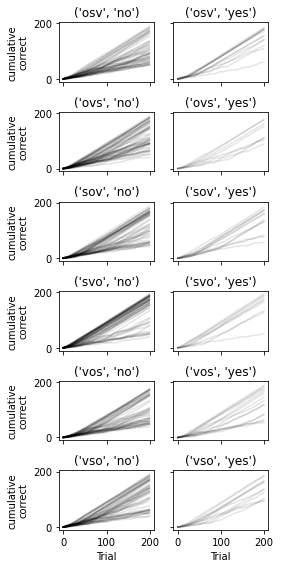

In [16]:
cumright = (history_choices_indices == 0).cumsum(0)

fig, axes = plt.subplots(
    6,
    2, 
    sharex=True, 
    sharey=True,
    figsize=(4,8)
)

for ax, (order, i) in zip(axes.flatten(), word_order_partic_df.groupby(['response', 'notes'])):
    
    ax.plot(
        cumright[:,i['rank_partic']], 
        alpha=0.1,
        color='black'
    )
    ax.set_title(order)

for ax in axes[-1]:
    ax.set_xlabel('Trial')
for ax in axes[:,0]:
    ax.set_ylabel('cumulative\ncorrect')
    
plt.tight_layout()
plt.show()

# Model-free analysis

In [17]:
import bambi as bmb

In [18]:
join_cols_f = lambda x: '|'.join(x.astype(str))

In [19]:
# the right choice is always 0
# Simplify to just whether the participant gets it right
# (Without further modelling structure the other three options are
# not structured)
right_answers = history_choices_indices == 0

In [20]:
trial_index, participant_index = np.indices(history_choices_indices.shape)

In [21]:
bmb_df = pd.DataFrame(
    data={
        'trial': trial_index.flatten(),
        'partic': participant_index.flatten(),
        # word orders
        'order': np.apply_along_axis(
            join_cols_f, 
            1, 
            np.tile(
                orders, 
                (200,1)
            )
        ),
        # signals,
        'right': right_answers.flatten()
    }
)

In [22]:
bmb_df.loc[:,'order_id'], order_codes = pd.factorize(
    bmb_df['order']
)

In [23]:
bmb_df.loc[:, 'scaled_trial'] = bmb_df.trial / bmb_df.trial.max()

In [24]:
np.unique(bmb_df[bmb_df['trial']==2]['order_id'], return_counts=True)

(array([0, 1, 2, 3, 4, 5]), array([64, 66, 64, 64, 64, 64]))

In [25]:
bmb_df.isna().any(axis=1).sum()

0

In [27]:
model = bmb.Model(
     "right ~ scaled_trial + order_id + (1|partic)",
    family='bernoulli',
    link='logit',
    categorical=['order_id', 'partic'],
    data=bmb_df
)
model.build()

In [31]:
try:
    results = az.from_netcdf(
        'trace_modelfree.cdf'
    )
except FileNotFoundError:
    results = model.fit(
        chains=4, 
        cores=1,
        draws=3000
    )
    # predict datapoints on the probability scale
    model.predict(results)
    az.to_netcdf(results, 'trace_modelfree.cdf')

Sampling: [1|partic_sigma, Intercept, order_id, scaled_trial]


array([[<AxesSubplot:title={'center':'Intercept'}>,
        <AxesSubplot:title={'center':'scaled_trial'}>,
        <AxesSubplot:title={'center':'order_id\n1'}>,
        <AxesSubplot:title={'center':'order_id\n2'}>],
       [<AxesSubplot:title={'center':'order_id\n3'}>,
        <AxesSubplot:title={'center':'order_id\n4'}>,
        <AxesSubplot:title={'center':'order_id\n5'}>,
        <AxesSubplot:title={'center':'1|partic_sigma'}>]], dtype=object)

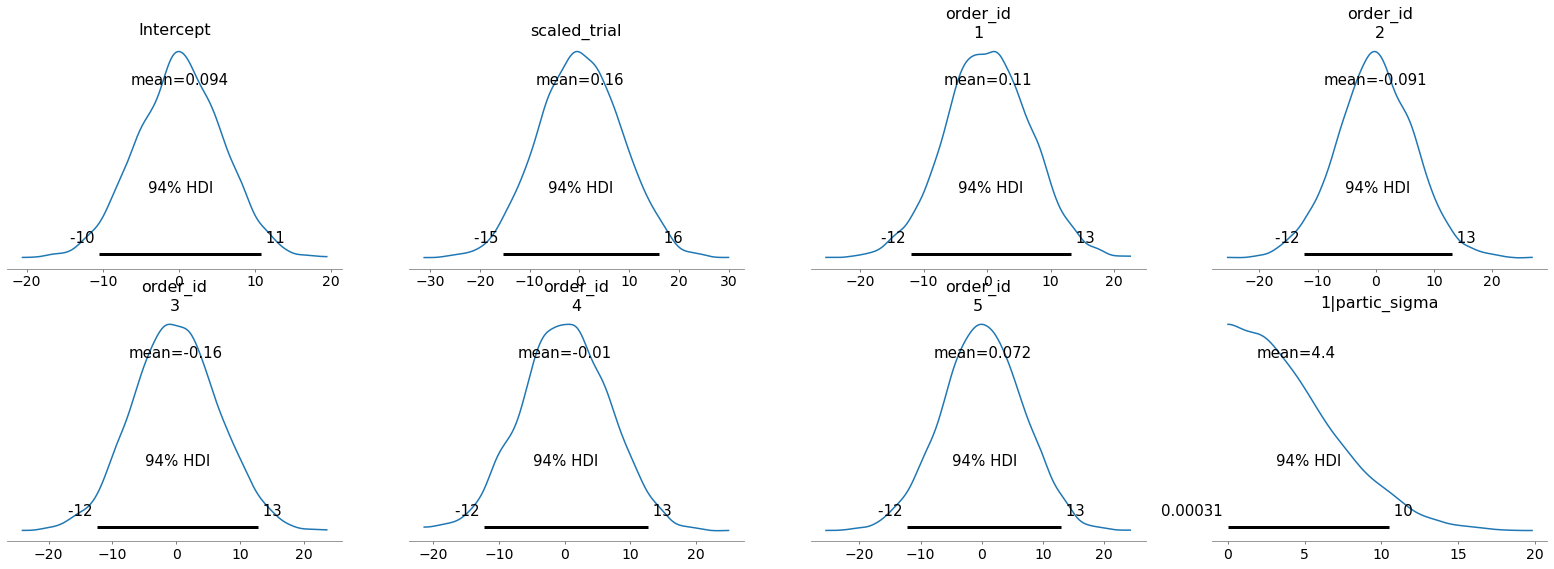

In [32]:
model.plot_priors()

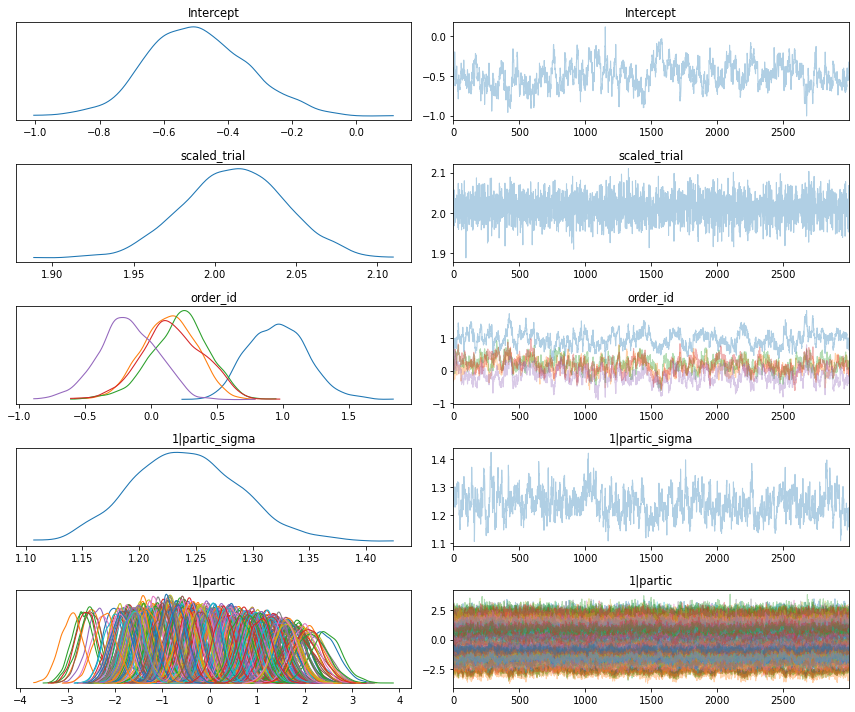

In [33]:
az.plot_trace(results)
plt.tight_layout()

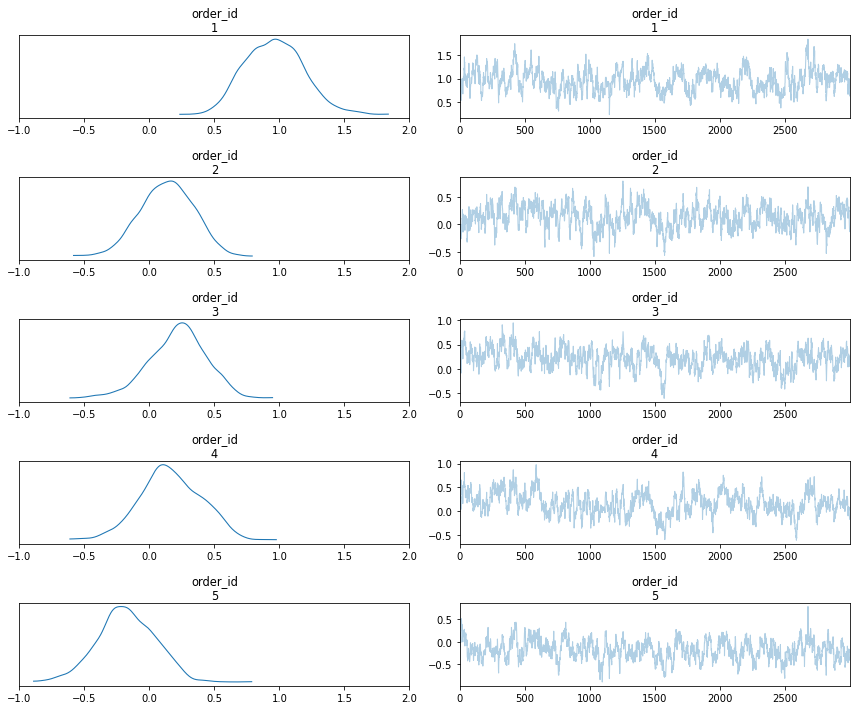

In [40]:
axes = az.plot_trace(
    results, 
    var_names=['order_id'], 
    compact=False
)
[ax.set_xlim(-1, 2) for ax in axes[:,0].flatten()]
plt.tight_layout()

In [46]:
results

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

In [54]:
bmb_df.loc[:,'predicted_mu'] = results.posterior.right_mean.mean(axis=(0,1))
bmb_df.loc[:,'predicted_var'] = results.posterior.right_mean.var(axis=(0,1))

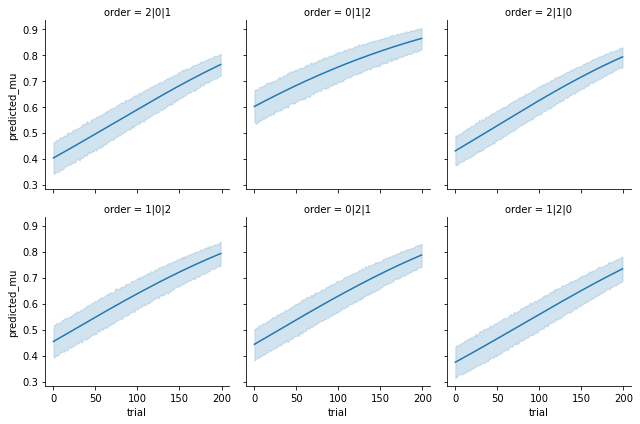

In [64]:
fg = sns.FacetGrid(
    bmb_df,
    col='order',
    col_wrap=3
)

fg.map(
    sns.lineplot,
    'trial',
    'predicted_mu'
)

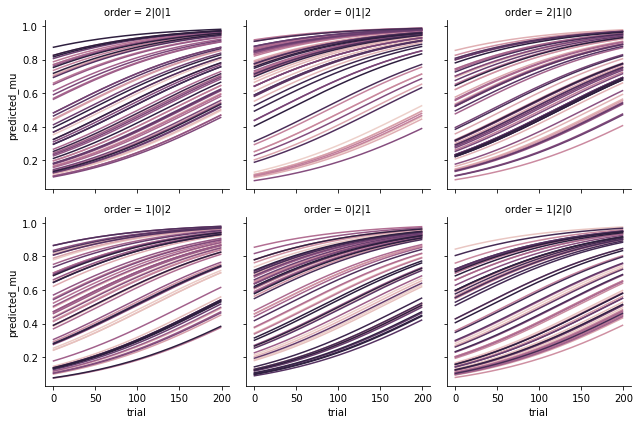

In [63]:
fg = sns.FacetGrid(
    bmb_df,
    col='order',
    col_wrap=3
)

fg.map(
    sns.lineplot,
    'trial',
    'predicted_mu',
    'partic'
)

In [76]:
# get the actual predicted intercepts
# from the reduced rank coding used by Bambi
predicted_intercepts = np.row_stack((
    results.posterior.Intercept.values.flatten(),
    (results.posterior.Intercept + results.posterior.order_id).values.reshape(-1,5).T
))

In all samples, the predicted intercept for the svo word order is higher than for all other word orders!

In [83]:
(predicted_intercepts[1] > predicted_intercepts).mean(1)

array([1., 0., 1., 1., 1., 1.])

# Some shared functions

In [15]:
def normalize(arr, axis=0):
    return arr / arr.sum(axis, keepdims=True)

In [16]:
def define_objects(n_beings=4, n_actions=3, full_output=False):
    
    # call beings with [0,1,2,3]
    being = range(n_beings)
    # call actions with [4,5,6]
    # NOTE: calling beings and actions 
    # with different numbers is useful below
    # when using them as indices of the language array
    actions = range(n_beings, n_beings+n_actions)
    signals = range(n_beings+n_actions)

    # columns: (agent, action, patient)
    # E.g. [0,0,1] means 'first being as agent, first action, second being as patient'
    scenes = np.array([
        i
        for i in it.product(being, actions, being)
        # Note: agent and patient can't be the same
        if i[0] != i[2]
    ])

    # Contains the possible interpretation 
    # functions, modelled as a function from
    # meanings to signals
    # For instance [2,1,3,...]
    # Means that meaning 0 has signal 2
    # meaning 1 has signal 1 etc.
    # Shape: (function, signal index)
    language_interpret = np.array(list(it.permutations(signals)))

    # Possible word orders 
    # 0: S, 1: V, 2: O
    word_orders = np.array(list(it.permutations(range(3))))

    # For every combination of interpretation function, 
    # word order, and scene, I need to produce which three words 
    # would be used by the language for that scene.

    # Contains for each language and scene
    # The index of the three signals that 
    # describe the scene in that language
    # dims: (interpretation function, word order, scene, 3)
    languages = []
    # for each interpretation function
    for inter in language_interpret:
        sub = []
        # for each word order
        for order in word_orders:
            subsub = []
            # for each scene
            # scene has: (agent, action, patient)
            for scene in scenes:
                # signals for [agent, action, patient]
                subsub.append(inter[scene][order])
            sub.append(subsub)
        languages.append(sub)
    languages = np.array(languages)
    
    if full_output:
        return scenes, languages, language_interpret, np.array(word_orders)
    return scenes, languages


def generate_trials(lang, n, scenes, n_scenes_trial):
    """
    Generate n trials from lang.
    Parameters
    ----------
    lang: array
        An array with shape (36,3)
        Containing for each scene 
        the three words used for that scene
    n: int
        The number of trials to return
    scenes: array
        The array containing the scenes
        see above for description of array
    n_scenes_trial: int
        The total number of scenes shown in each trial
        (one is true and others are confounders)
    Returns
    -------
    list of arrays
        Each array has len (trials)
        (true_scene_index, four possible choices, utterance)
    """
    index_scenes = np.array([
        np.random.choice(
            len(scenes), 
            4,
            replace=False
        )
        for _ in range(n)
    ])
    
    true_scenes_index = np.random.choice(
        np.arange(n_scenes_trial), 
        size=len(index_scenes)
    )
    true_scenes = index_scenes[
        np.arange(len(index_scenes)),
        true_scenes_index
    ]
    utterances = lang[true_scenes]
    
    return true_scenes, index_scenes, utterances


def define_priors(word_orders, language_interpret):
    word_order_prior = normalize(
        np.array([1]*len(word_orders))
    ) # normalize([1,1,1,1,1,5])
    interpret_prior = normalize(
        np.array([1]*len(language_interpret))
    )
    return word_order_prior, interpret_prior

The functions in this cell run the perfect Bayesian learner, but they are here because they're also used below to simulate experiments:

In [17]:
def choose_scene(utterance_by_language, indices_scenes, current_state):
    """
    Choose a scene based on current posterior
    by sampling with model averaging.
    The main step is to restrict to the 4 available scenes
    and to the given utterance.
    Get for each scene P(scene | utterance, language)P(language)
    And then sum across languages
    """
    # Joint probability of each scene & language
    # given the utterance.
    # restrict to just available scenes
    p_lang_scene_given_utt = utterance_by_language[:,:,indices_scenes] 
    # multiply with prior over languages
    p_lang_scene_given_utt = p_lang_scene_given_utt * current_state[:,:,None]
    # sum over languages to get probability of 
    # each of the four scenes given the utterance
    p_scene = normalize(p_lang_scene_given_utt, axis=(0,1,2)).sum((0,1))
    chosen_scene = np.random.choice(indices_scenes, p=p_scene)
    return chosen_scene


def update_knowledge(chosen_scene, true_scene, languages, utterance, 
                     indices_scenes, current_state, negative_evidence):
    """
    Update current knowledge with Bayesian update
    """
    
    if chosen_scene == true_scene:
        # update current_state to only keep those languages
        # that are compatible with that scene and utterance
        compatible_languages = (languages == utterance).all(-1)[:,:,chosen_scene]
    elif negative_evidence:
        # otherwise it's one of the remaining three 
        # observed scenes

        # Get indices of non chosen scenes
        indices_non_chosen = indices_scenes[indices_scenes!=chosen_scene]
        # Mask for languages that use the seen utterance
        # for any of the non-chosen scenes
        compatible_languages = (languages == utterance).all(-1)[:,:,indices_non_chosen].any(-1)
    else:
        compatible_languages = np.ones_like(current_state)
    current_state = normalize(compatible_languages*current_state, axis=(0,1))
    return current_state
    

def run_experiment(trials, interpret_prior, word_order_prior, negative_evidence):
    
    # dims: (interpretation function, word order)
    # Contains the probabilities of each language,
    # encoded as a combination of intepretation function 
    # and word order
    current_state = interpret_prior[:,None] * word_order_prior

    # loop through the observations and update the posterior
    # at each timestep
    history_states = [current_state]
    history_choices = []
    for true_scene, indices_scenes, utterance in zip(*trials):

        # get indicator of utterance for each language
        # NOTE: some languages don't use a certain
        # utterance at all!
        # This gives P(scenes | language, utterance)
        # Which is always 0 or 1
        utterance_by_language = (languages == utterance).all(-1)

        chosen_scene = choose_scene(
            utterance_by_language, 
            indices_scenes, 
            current_state
        )
        
        history_choices.append(chosen_scene)

        current_state = update_knowledge(
            chosen_scene, 
            true_scene, 
            languages, 
            utterance, 
            indices_scenes,
            current_state,
            negative_evidence
        )
        history_states.append(current_state)
        
    return history_states, history_choices

In [18]:
def simulate_full_experiment(n_trials, n_participants, 
                             true_languages_setting, simulate_responses):
    """
    Simulate data from multiple perfeclty bayesian participants
    
    Parameters
    ----------
    simulate_responses: bool
        Whether the dependent variable is simulated
    """

    scenes, languages, language_interpret, word_orders = define_objects(
        full_output=True
    )

    word_order_prior, interpret_prior = define_priors(
        word_orders, 
        language_interpret
    )

    true_scenes = []
    indices_scenes_trials = []
    signals = []
    
    if simulate_responses:
        history_states = []
        history_choices = []
        history_choices_indices = []

    f = IntProgress(min=0, max=n_participants)
    display(f) 

    if true_languages_setting == 'half':
        # pick a random true language
        # (interpretationfunction, word_order)
        indices_true_language = (
            [
                (
                    np.random.randint(low=0, high=len(languages)), 
                    np.random.randint(low=0, high=6)
                )
            ]*(n_participants//2) +
            [
                (
                    np.random.randint(low=0, high=len(languages)), 
                    np.random.randint(low=0, high=6)
                )
            ]*(n_participants//2)
        )
        
    elif true_languages_setting == 'unique':
        ### Train each participant on different lang
        indices_true_language = [
            (
                np.random.randint(low=0, high=len(languages)), 
                np.random.randint(low=0, high=6)
            ) 
            for _ in range(n_participants)
        ]
        
    elif true_languages_setting == 'same':
        ### Train all on the same language
        indices_true_language = [
            (
                np.random.randint(low=0, high=len(languages)), 
                np.random.randint(low=0, high=6)
            ) 
        ] * n_participants
        
    else:
        raise ValueError('Setting unknown!')


    for i in range(n_participants):

        index_true_language = indices_true_language[i]

        trials = generate_trials(
            languages[index_true_language], 
            n=n_trials, 
            scenes=scenes, 
            n_scenes_trial=4
        )

        t_scenes, i_scenes_trials, sign = trials

        true_scenes.append(t_scenes)
        indices_scenes_trials.append(i_scenes_trials)
        signals.append(sign)

        if simulate_responses:
            
            # Run perfect Bayesian learner here
            h_states, h_choices = run_experiment(
                trials, 
                interpret_prior, 
                word_order_prior, 
                negative_evidence=False
            )

            history_states.append(h_states)
            history_choices.append(h_choices)

            # go from the actual chosen scenes to their indices
            history_choices_indices.append(
                np.argwhere(
                    i_scenes_trials == np.array(h_choices)[:,None]
                )[:,1]
            )

        f.value += 1

    # transform into numpy arrays AND reshuffle 
    # so trial is first dimension (which is needed below when using `scan`)
    true_scenes = np.swapaxes(true_scenes, 0, 1)
    indices_scenes_trials = np.swapaxes(indices_scenes_trials, 0, 1)
    signals = np.swapaxes(signals, 0, 1)

    scenes_trials = scenes[indices_scenes_trials]
    true_scenes_trials = scenes[true_scenes]
    
    returndict = {
        'true_scenes': true_scenes, 
        'indices_scenes_trials': indices_scenes_trials, 
        'signals': signals, 
        'scenes_trials': scenes_trials, 
        'true_scenes_trials': true_scenes_trials,
        'indices_true_language': np.array(indices_true_language)
    }
    
    if simulate_responses:
        
        history_states = np.swapaxes(history_states, 0, 1)
        history_choices = np.swapaxes(history_choices, 0, 1)
        history_choices_indices = np.swapaxes(history_choices_indices, 0, 1)
        
        returndict.update({
            'history_states': history_states, 
            'history_choices': history_choices, 
            'history_choices_indices': history_choices_indices
        })
    return returndict

# Basic Bayesian model of joint inference

## Run simulated experiments

In [323]:
scenes, languages, language_interpret, word_orders = define_objects(
    full_output=True
)
word_order_prior, interpret_prior = define_priors(
    word_orders, 
    language_interpret
)

In [63]:
index_true_language = (2,3)

trials = generate_trials(
    languages[index_true_language], 
    10, 
    scenes, 
    4
)

In [64]:
history, _ = run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=True
)

In [65]:
[h[index_true_language] for h in history]

[3.3068783068783064e-05,
 0.002314814814814815,
 0.25,
 0.5,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

## Run multiple experiments

In [44]:
def run_experiments(index_true_lang, interpret_prior, word_order_prior, n, negative_evidence):
    
    scenes, languages = define_objects()
    word_order_prior, interpret_prior = define_priors()
    
    f = IntProgress(min=0, max=n)
    display(f)

    histories = []
    for i in range(n):
        index_lang = (
            index_true_lang 
            if type(index_true_lang) is tuple
            else index_true_lang[i]
        )
        trials = generate_trials(
            languages[index_lang], 
            10, 
            scenes, 
            4
        )
        histories.append(
            run_experiment(
                trials, 
                interpret_prior, 
                word_order_prior,
                negative_evidence
            )[0]
        )
        f.value += 1
    return histories

### Considering negative evidence

In [ ]:
index_true_language = (2,3)

In [ ]:
histories = run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=True
)

In [ ]:
true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

In [ ]:
means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()

### Without considering negative evidence

In [ ]:
index_true_language = (2,3)

In [ ]:
histories = run_experiments(
    index_true_language, 
    interpret_prior, 
    word_order_prior, 
    n=100,
    negative_evidence=False
)

In [ ]:
true_hists = [
    [h[index_true_language] for h in history]
    for history in histories
]

In [ ]:
means, variances = np.mean(true_hists, 0), np.var(true_hists, 0)

In [ ]:
fig, ax = plt.subplots()
ax.errorbar(np.arange(len(means)), means, variances)
ax.set_xlabel('trial')
ax.set_ylabel('Probability of true language')
plt.show()

# Get learned language features directly from answers

A very simple model is to empirically check when people have learned the language features (word meanings + word order).

Model:
- Each participant over timesteps is encoded as a strictly increasing set of known language features.
- In particular: 
    - What each word refers to (assuming bijection between words and objects)
    - Where the verb, object, and subject is (partial knowledge is possible)
- Crucial part of the model: 
    - We know what the _true_ language is, and we know that if participants don't have the true language they'll get feedback that contradict their choices. 
    - Therefore, we can just keep track of which of the TRUE language features a participant has learned, and assume participants just sample randomly from the language until they figured out the true one.
    - In a sense, this model disregards the feedback given to participants. Just uses their choices to infer what they know at each timestep. However, it _depends_ on participants having to explore until they get to the true language, which depends on them getting feedback.
    - This model can be conceptualized as a multidimensional switchpoint model, where for each language feature, the participant goes from uniform probability (or something like that) before a certain point (the point where they figure out that language feature) to putting all probability to the true feature after a certain point (when they figure out the language).
- Crucial simplification: we don't model what _other_ language the participant is learning, just whether they have already learned the true language. The simplification is that we assume that if participants haven't yet learned the true feature, they don't believe in _another_ feature but rather just do exploration.
- Another way of looking at this is that we know what the participants will do _eventually_, namely figure out the truth, but how they do it is so complicated that we can encode it as noise. We just can't explicitly model what they mistakenly think they've learned in between.
- Having participant-wise hierarchical structure for position of switchpoint allows us to do model-comparison on how easy participants find it to infer different word orders.

Behavioural assumptions:
- At each step, the participant's knowledge state is encoded just as a Boolean vector that contains for each language feature whether the participant has learned it already
    - The boolean vector can be constructed by > comparison with the inferred switchpoints
- A knowledge state induces at each timestep a distribution over the four choices.
    - Basically, the knowledge state excludes some of the options (the ones incompatible with what the participant knows)
    - The participant chooses e.g. uniformly among the remaining ones

Free parameters:
- For each participant, the free parameters are just the positions of the switchpoint for each language feature.

Language features. Participant knows:
- Position of verb
- Position of subject
- Position of object
- Word for meaning 1
- Word for meaning 2

...

- Word for meaning 7

Note that position of verb, position of subject, and position of object are partially independent from each other. The participant might have figured out where the verb is but might be unsure which position is for subject and which for object, and viceversa. Knowing any two determines where the third is, but a participant can know just one of them. Therefore, I need to add the restriction: 
- whichever two are learned last, they are learned together. 
- This restriction means that when we're sampling the timepoints at which the positions are learned, we're effectively sampling from a 2-d surface in discrete 3-d space s.t. the two dimensions with the highest value are always equal
- There's only three ways this can happen: L(low)-H(igh)-H, HLH, HHL (position indicates verb, subject, object respectively)
- Therefore, to sample I can:
    - First, sample two numbers between 0 and max, a L(ow) and a H(igh)
    - Second, sample an order from LHH, HLH, HHL
    - Third, construct the actual numbers
- Does this way of sampling produce a reasonable prior?

The most tricky thing with this model programming-wise is how to determine efficiently whether a state and utterance are compatible given a knowledge state.

- Knowledge state is encoded by two vectors: 
    - One vector with 3 components for word order
    - One vector with 7 components for word meanings
- A sentence is encoded as an array with shape (3,3,7) and dimensions (word index, verb/subject/object, word)
- A scene is encoded as an array with shape (3,7) and dimensions (action/agent/patient, meaning)

A scene and a sentence are compatible given a language iff the language would produce the sentence for the scene. That can be calculated as:

In [ ]:
import numpy as np

In [ ]:
def likelihood_f(compatible_langs, utterance, indices_scenes):
    """
    probability of each scene given the utterance
    NOTE: mostly same as choose_scene above
    """
    # languages that produce the observed utterance for each scene
    utterance_by_language = tt.eq(compatible_langs, utterance).all(-1)
    # restrict to just available scenes
    p_lang_scene_given_utt = utterance_by_language[:,:,indices_scenes] 
    # sum over languages to get probability of 
    # each of the four scenes given the utterance
    # shape (4)
    p_scene = normalize(p_lang_scene_given_utt, axis=(0,1,2)).sum((0,1))
    return p_scene

In [ ]:
def find_compatible_langs(interpret_knowledge, order_knowledge, true_interpret, 
                          true_order, word_orders, language_interpret, languages):
    
    # indices_compatible gives the indices
    # of the interpretation function compatible with 
    # interpret_knowledge
    # Indicator functions of languages compatible with current knowledge
    # shape (interpret funcs, word orders)
    interpret_indices_compatible = (
        ~interpret_knowledge | (language_interpret==true_interpret)
    ).all(axis=1)

    # NOTE: prima facie odd way of writing this, but note that it has to work
    # when order_knowledge is all 0!
    # Conceptually: a language is excluded only if it is *known to be wrong*
    # and included if it is compatible with everything that's known
    order_indices_compatible = (~order_knowledge | (word_orders==true_order)).all(axis=1)
    
    # get just languages that are compatible with current knowledge
    # about both interpretation and order
    compatible_langs = theano.shared(languages)[interpret_indices_compatible][:,order_indices_compatible]
    
    return compatible_langs

In [ ]:
# scene
scenes, languages, language_interpret, word_orders = define_objects(4,3, full_output=True)

In [ ]:
# languages encodes the signal produced by each scene in each lang
# dims: (interpretation function, word order, scene, 3)
print('languages shape: ', languages.shape)

## Calculate probability scenes for a single trial

In [ ]:
# gives the signal for each meaning of the true language
true_interpret = language_interpret[0]
# gives the true word order
true_order = word_orders[0]

In [ ]:
# interpret_knowledge says whether the signal
# for each meaning has been figured out yet
interpret_knowledge = np.array([1, 0, 0, 1, 0, 0, 0]).astype(bool)
# order_knowledge same but for word order
order_knowledge = np.array([1,1,1]).astype(bool)

In [ ]:
compatible_langs = find_compatible_langs(
    interpret_knowledge, order_knowledge, true_interpret, 
    true_order, word_orders, language_interpret, languages
)

In [ ]:
utterance = np.array([0,1,2])
indices_scenes = np.array([0,1,2,3])
p_scenes = likelihood_f(compatible_langs, utterance, indices_scenes)

In [ ]:
# add noise!
p_scenes = normalize(p_scenes + np.random.exponential(scale=0.01))

In [ ]:
p_scenes

## Calculate probabilities for one whole participant

In [ ]:
def calculate_p_scenes(utterance, indices_scenes, noise, **kwargs):
    # Find compatible languages for each timestep
    compatible_langs = find_compatible_langs(**kwargs)
    p_scenes = likelihood_f(
        compatible_langs, 
        utterance, 
        indices_scenes
    )
    # add noise!
    p_scenes = normalize(p_scenes + noise)
    return p_scenes

In [ ]:
index_true_language = (2,3)
n_trials = 20

trials_arange = np.arange(n_trials)

# True interpretation function
true_interpret = language_interpret[index_true_language[0]]
# True word order
true_order = word_orders[index_true_language[1]]

trials = generate_trials(
    lang=languages[index_true_language], 
    n=n_trials, 
    scenes=scenes,
    n_scenes_trial=4
)

# indices_scenes_trials contains the four scenes' indices 
# seen in each trial
# (trial, 4)
# utterances_trials containg the three signals 
# observed in each trial
# (trial, 3)
_, indices_scenes_trials, utterances_trials = trials

In [ ]:
history_states, history_choices = run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=False
)

# go from the actual chosen scenes to their indices
history_choices_indices = np.argwhere(
    indices_scenes_trials == np.array(history_choices)[:,None]
)[:,1]

In [ ]:
with pm.Model() as model:
    
    noise = pm.Exponential(
        'noise',
        lam=6
    )
    # noise = tt.zeros(1)
    
    # interpret_discovery_timestep says for each
    # meaning at which timestep the signal for 
    # that meaning was found
    interpret_discovery_timestep = pm.DiscreteUniform(
        'index_discovered_interpret',
        lower=0, 
        upper=n_trials,
        shape=language_interpret.shape[1]
    )
    
    # interpret_discovery_timestep says for each
    # meaning at which timestep the signal for 
    # that meaning was found
    order_discovery_timestep = pm.DiscreteUniform(
        'index_discovered_order',
        lower=0, 
        upper=n_trials,
        shape=word_orders.shape[1]
    )
    
    # interpret_knowledge for each trial
    # dimensions: (trial, meaning)
    interpret_knowledge_trials = np.tile(
        trials_arange[:,None], 
        (1, language_interpret.shape[1])
    ) >= interpret_discovery_timestep
    
    # dimensions: (trial, 3)
    order_knowledge_trials = np.tile(
        trials_arange[:,None], 
        (1, word_orders.shape[1])
    ) >= order_discovery_timestep
    
    # results contains for each trial
    # the probability of the agent selecting 
    # each scene
    results,_ = theano.scan(
        fn=lambda i: calculate_p_scenes(
            theano.shared(utterances_trials)[i],
            theano.shared(indices_scenes_trials)[i],
            noise,
            # kwargs for find_compatible_langs
            interpret_knowledge = interpret_knowledge_trials[i], 
            order_knowledge = order_knowledge_trials[i], 
            true_interpret = true_interpret, 
            true_order = true_order, 
            word_orders = word_orders, 
            language_interpret = language_interpret, 
            languages = languages
        ),
        sequences=tt.arange(n_trials)
    )
    
    theano.printing.Print()(results)
    theano.printing.Print('interpret discovery')(interpret_knowledge_trials)
    theano.printing.Print('order discovery')(order_knowledge_trials)
    
    pm.Categorical('choices', p=results, observed=history_choices_indices)

In [ ]:
with model:
    samples = pm.sample(
        draws=3000, 
        return_inferencedata=True
    )

In [ ]:
az.plot_trace(samples,compact=False)
plt.tight_layout()
plt.show()

# Association weights model

## Description

This is a model of non-perfectly-Bayesian learning where at each timestep the associations between meaning-words, as well as word orders, are strenghtened (if they are compatible with the observation) or weakened (if they are not).

This is the model described in the PPT presentation

For word-meaning association array:

I only update the rows corresponding to the words used in the signal. For instance:
- If the signal is [0, 4, 2] I update rows 0, 4, and 2 

I only update the columns corresponding to the components of the scene. For instance:
- If the scene is [2, 5, 0] I update columns 2, 5, and 0.

Each row/col combination is updated by the probability of the word (row) being the one for the object (column), across all the word orders. For instance:
- Suppose the first word in the signal is 0 and the subject in the scene is object 2
- Then I want to increment the weight for element (0,2) in interpret_weights by the probability that word 0 is the one referring to object 2. 
    - This happens iff the word order is SOV or SVO (this behaves a lot like a likelihood)
- And this is repeated for each column / row

Snippet A in `update_weights` can be replaced by:

```python
# add prob that first word expresses the observed subject,
# i.e., the sum of the probabilities of the word orders that have 
# the subject in the first position
interpretation_weights[firstword, subj] += word_order_weights[[0,1]].sum()
# add prob that second word expresses the observed subject
interpretation_weights[secondword, subj] += word_order_weights[[2,4]].sum()
# add prob that third word expresses the observed subject
interpretation_weights[thirdword, subj] += word_order_weights[[3,5]].sum()

# add prob that first word expresses observed object
interpretation_weights[firstword, obj] += word_order_weights[[4,5]].sum()
# add prob that second word expresses observed object
interpretation_weights[secondword, obj] += word_order_weights[[1,3]].sum()
# add prob that third word expresses observed object
interpretation_weights[thirdword, obj] += word_order_weights[[0,2]].sum()

# add prob that first word expresses observed action
interpretation_weights[firstword, act] += word_order_weights[[2,3]].sum()
# add prob that second word expresses observed action
interpretation_weights[secondword, act] += word_order_weights[[0,5]].sum()
# add prob that third word expresses observed action
interpretation_weights[thirdword, act] += word_order_weights[[1,4]].sum()
```

and snippet B by:

```python
# prob of each word order combo
# following the word_orders array
# and the word_order_weights array
# Equivalent to:
# SVO
word_order_weights[0] += interpretation_weights[signal, [subj, act, obj]].prod()
# SOV
word_order_weights[1] += interpretation_weights[signal, [subj, obj, act]].prod()
# VSO
word_order_weights[2] += interpretation_weights[signal, [act, subj, obj]].prod()
# VOS
word_order_weights[3] += interpretation_weights[signal, [act, obj, subj]].prod()
# OSV
word_order_weights[4] += interpretation_weights[signal, [obj, subj, act]].prod()
# OV
word_order_weights[5] += interpretation_weights[signal, [obj, act, subj]].prod()
```

## Simulate experiment in numpy

In [20]:
def update_weights(interpretation_weights_original, word_order_weights_original, scene, signal):

    subj, act, obj = scene
    firstword, secondword, thirdword = signal
    
    interpretation_weights = interpretation_weights_original.copy()
    word_order_weights = word_order_weights_original.copy()

    ### Snippet A

    # get mask for the indices that I wrote above for word_order_weights
    mask_orders = (
        np.tile(word_orders[None], (3,1,1)) 
        == 
        np.array([0,1,2])[:,None,None]
    )
    # get the values from word_order_weights
    # to add to the various elements
    # rows: (subj, obj, act)
    # cols: (first word, second word, third word)
    values_to_add = word_order_weights @ mask_orders
        
    # add value to right locations
    interpretation_to_add = np.zeros_like(
        interpretation_weights
    )
    
    interpretation_to_add[
        np.tile(signal[None], (3,1)), 
        np.tile(scene.reshape(-1,1), (1,3))
    ] = values_to_add
        
    interpretation_weights = normalize(
        interpretation_weights + interpretation_to_add,
        axis=1
    )
    
    # Snippet B
    
    word_order_to_add = interpretation_weights_original[
        np.tile(signal[None], (6,1)), 
        scene[word_orders]
    ].prod(1)
    
    word_order_weights = normalize(
        word_order_weights_original + 
        word_order_to_add
    )
    
    return interpretation_weights, word_order_weights    

In [59]:
n_trials = 40
# (interpretation function, word_order)
index_true_language = (2,3)

In [66]:
scenes, languages, language_interpret, word_orders = define_objects(
    full_output=True
)

word_order_prior, interpret_prior = define_priors(
    word_orders, 
    language_interpret
)

trials = generate_trials(
    languages[index_true_language], 
    n=n_trials, 
    scenes=scenes, 
    n_scenes_trial=4
)

true_scenes, indices_scenes_trials, signals = trials

history_states, history_choices = run_experiment(
    trials, 
    interpret_prior, 
    word_order_prior, 
    negative_evidence=False
)

# go from the actual chosen scenes to their indices
history_choices_indices = np.argwhere(
    indices_scenes_trials == np.array(history_choices)[:,None]
)[:,1]

[1 6 2] [6 2 1] 



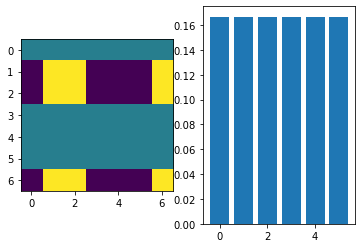

[0 4 2] [5 2 0] 



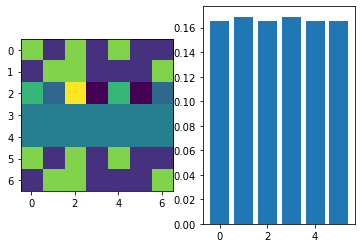

[1 6 3] [6 3 1] 



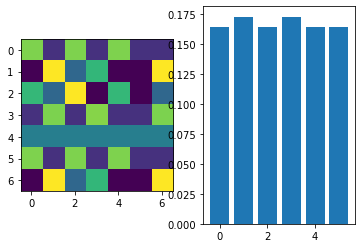

[1 6 3] [6 3 1] 



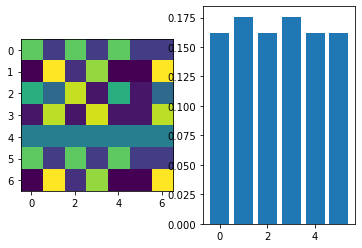

[1 4 0] [5 0 1] 



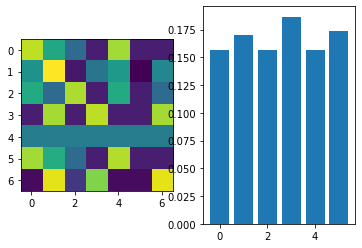

[3 6 0] [6 0 3] 

[2 6 3] [6 3 2] 

[0 5 1] [4 1 0] 

[0 5 2] [4 2 0] 

[2 6 0] [6 0 2] 

[1 4 2] [5 2 1] 

[0 6 3] [6 3 0] 

[3 6 0] [6 0 3] 

[2 6 3] [6 3 2] 

[2 4 0] [5 0 2] 

[1 6 3] [6 3 1] 

[1 6 0] [6 0 1] 

[2 5 0] [4 0 2] 

[1 6 2] [6 2 1] 

[1 6 3] [6 3 1] 

[3 4 2] [5 2 3] 

[0 5 3] [4 3 0] 

[3 6 1] [6 1 3] 

[2 6 0] [6 0 2] 

[0 6 1] [6 1 0] 

[1 4 3] [5 3 1] 

[3 4 2] [5 2 3] 

[0 6 3] [6 3 0] 

[2 5 0] [4 0 2] 

[0 4 1] [5 1 0] 

[0 4 1] [5 1 0] 

[0 6 3] [6 3 0] 

[1 6 3] [6 3 1] 

[1 4 0] [5 0 1] 

[2 6 3] [6 3 2] 

[2 5 1] [4 1 2] 

[0 4 2] [5 2 0] 



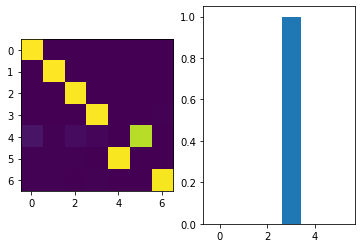

[0 6 3] [6 3 0] 



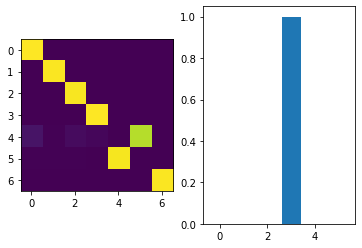

[2 6 0] [6 0 2] 



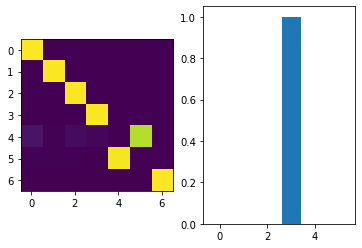

[2 5 3] [4 3 2] 



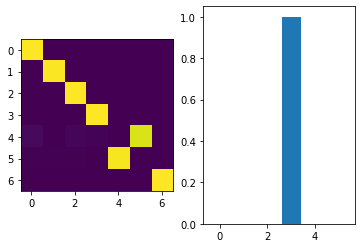

In [66]:
# dims (word, meaning)
# probability that each word has each meaning
interpretation_weights = normalize(
    np.ones((7,7)),
    axis=1
)

# dims (word order)
word_order_weights = normalize(
    np.ones(6)
)

for i, (true_scene_index, signal) in enumerate(zip(true_scenes, signals)):
    
    true_scene = scenes[true_scene_index]
    
    print(true_scene, signal, '\n')
    
    interpretation_weights, word_order_weights = update_weights(
        interpretation_weights, 
        word_order_weights, 
        true_scene, 
        signal
    )
    
    # print(word_order_weights)
    # print(interpretation_weights)
    
    if (i < 5) or (i > len(true_scenes)-5):
        fig, (ax1, ax2) = plt.subplots(1,2)
        ax1.imshow(interpretation_weights)
        ax2.bar(np.arange(len(word_order_weights)), word_order_weights)
        plt.show()

## In pymc3

### Single participant

In [55]:
def theano_normalize(tensor, axis):
    return tensor / tensor.sum(axis, keepdims=True)

In [56]:
def update_weights_theano(scene, signal, interpretation_weights_original, 
                          word_order_weights_original, word_orders):
    
    ### Snippet A

    # get mask for the indices that I wrote above 
    # where I described how to update the array
    # for word_order_weights
    mask_orders = tt.eq(
        tt.tile(word_orders, (3,1,1)), 
        np.array([0,1,2])[:,None,None]
    )
    
    # get the values from word_order_weights
    # to add to the various elements
    # rows: (subj, obj, act)
    # cols: (first word, second word, third word)
    values_to_add = tt.batched_dot(
        tt.tile(word_order_weights_original, (3,1)), 
        mask_orders
    )
        
    # add value to right locations
    interpretation_to_add = tt.set_subtensor(
        tt.zeros(interpretation_weights_original.shape)[
            tt.tile(signal, (3,1)), 
            tt.tile(scene.dimshuffle(0, 'x'), 3)
        ],
        values_to_add
    )
    
    # normalize last dimension
    interpretation_weights = theano_normalize(
        interpretation_weights_original + 
        interpretation_to_add,
        axis=-1
    )
    
    # Snippet B
    
    word_order_to_add = interpretation_weights_original[
        tt.tile(signal.dimshuffle('x', 0), (6,1)), 
        scene[word_orders]
    ].prod(1)
    
    word_order_weights = (
        word_order_weights_original + 
        word_order_to_add
    )
    
    word_order_weights = theano_normalize(
        word_order_weights,
        0
    )
    
    return interpretation_weights, word_order_weights


def probs_languages_to_probs_scenes(interpretation_weights, word_order_weights, 
                                    signals, scenes_trials, word_orders):
    """
    Finds probability of choosing each of the four scenes in `scenes`
    given the observed utterance and the current probabilities 
    of word-meaning association and word orders
    """
    
    # meaning that each word would be expressing
    # assuming each word order is true
    # dims (trial, scene in trial, word orders, 3), values: meanings
    meanings_trials_orders = scenes_trials[:,:,word_orders]
    
    return normalize(
        (
            # get the probability of the words observed
            # in each trial expressing each scene
            # assuming each word order in turn
            interpretation_weights[
                tt.arange(interpretation_weights.shape[0])[:,None,None,None],
                signals[:,None,None],
                meanings_trials_orders
            ]
            # get joint probability of the observed words
            # (for each trial, word order and scene)
            .prod(-1) 
            # multiply by probability of word orders
            * word_order_weights.dimshuffle(0, 'x', 1)
        # marginalize out word order
        # to get probs of observed words in scene
        ).sum(-1),
        1
    )

In [67]:
with pm.Model() as model:
    
    # dims (word, meaning)
    # Initial (fixed, not estimated) prior over
    # interpretations
    interpretation_weights = theano_normalize(
        tt.ones((7,7)),
        axis=1
    )
    
    # shape 6
    # Estimated Dirichlet prior over word orders
    word_order_weights = pm.Dirichlet(
        'word_order_prior', 
        [1]*6
    )
    
    # scan is theano's way to do looping.
    # Returns probs of each word-meaning connection
    # and each word order respectively
    (probs_interpretations, probs_word_orders), outputs_info = theano.scan(
        update_weights_theano,
        sequences=[
            theano.shared(scenes[true_scenes]),
            theano.shared(signals)
        ],
        outputs_info=[
            interpretation_weights,
            word_order_weights
        ],
        non_sequences=[
            word_orders
        ],
        profile=True,
        name='update weights'
    )
    
    # Calculate the probability of each choice
    # In each trial
    # dims (trial, scenes in trial)
    prob_scenes = probs_languages_to_probs_scenes(
        probs_interpretations, 
        probs_word_orders, 
        signals, 
        scenes[indices_scenes_trials], 
        word_orders
    )
    
    pm.Categorical(
        'chosen_scenes',
        p=prob_scenes,
        observed=history_choices_indices
    )

In [68]:
with model:
    trace = pm.sample(
        return_inferencedata=True
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [word_order_prior]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 56 seconds.


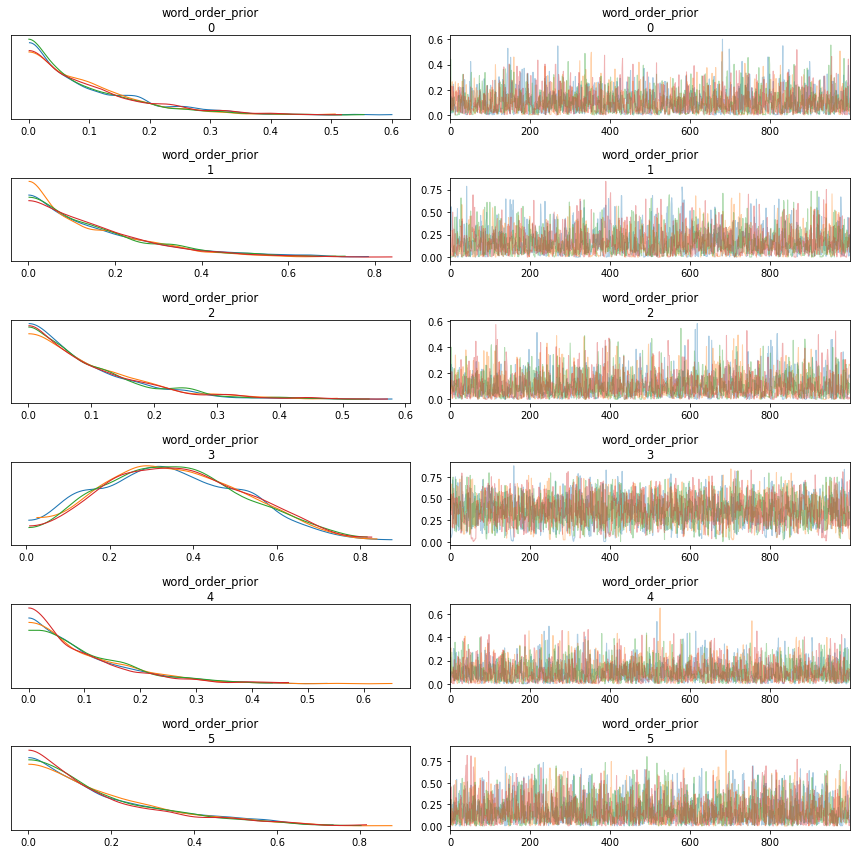

In [69]:
az.plot_trace(trace, compact=False)
plt.tight_layout()
plt.show()

In [70]:
with model:
    fit = pm.fit()

Finished [100%]: Average Loss = 3.8781


In [81]:
with model:
    fit_samples = az.from_pymc3(fit.sample(5000))

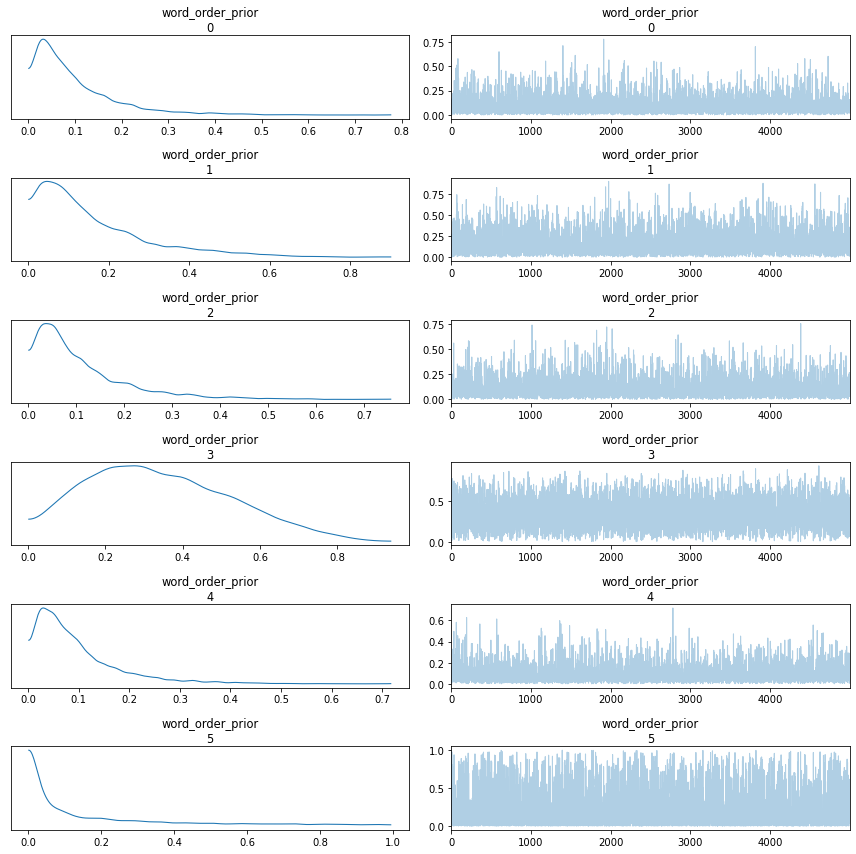

In [87]:
az.plot_trace(fit_samples, compact=False)
plt.tight_layout()
plt.show()

#### Profiling the model to speed it up

Profiling the model shows that 93% of the time is spent on the scan operation.

```python
model.profile(model.logpt).summary()
```

Since it's difficult to look inside the scan, it makes sense to just run the `update_weights_theano` function by itself:

In [113]:
theano.config.compute_test_value = 'ignore'
scene = tt.vector('scene', 'int32')
signal = tt.vector('signal', 'int32')
interpretation_weights = tt.matrix('int weights', dtype='float32')
word_order_weights = tt.matrix('word order weights', dtype='float32')

output = update_weights_theano(
    scene, 
    signal, 
    interpretation_weights, 
    word_order_weights, 
    word_orders
)

f = theano.function(
    inputs = [
        scene,
        signal,
        interpretation_weights,
        word_order_weights
    ],
    outputs = output,
    profile=True
)

theano.config.compute_test_value = 'raise'

second arg __str__ = [3 6 3]


In [115]:
f.profile.summary()

Function profiling
  Message: /tmp/ipykernel_4773/2173517746.py:15
  Time in 0 calls to Function.__call__: 0.000000e+00s
  Total compile time: 9.236168e+00s
    Number of Apply nodes: 37
    Theano Optimizer time: 8.406754e-01s
       Theano validate time: 1.489878e-03s
    Theano Linker time (includes C, CUDA code generation/compiling): 8.364623069763184s
       Import time 3.022337e-02s
       Node make_thunk time 8.362206e+00s
           Node Elemwise{add,no_inplace}(word order weights, InplaceDimShuffle{x,0}.0) time 1.095055e+00s
           Node Elemwise{TrueDiv}[(0, 0)](Elemwise{add,no_inplace}.0, InplaceDimShuffle{x,0}.0) time 1.043028e+00s
           Node Elemwise{Add}[(0, 1)](int weights, AdvancedIncSubtensor{inplace=False,  set_instead_of_inc=True}.0) time 9.500339e-01s
           Node BatchedDot(Reshape{2}.0, TensorConstant{[[[1. 0. 0... 0. 0.]]]}) time 7.848408e-01s
           Node Alloc(signal, TensorConstant{3}, TensorConstant{1}, TensorConstant{1}, Shape_i{0}.0) time 7.80

In [105]:
profilemodel.profile(profilemodel.logpt).summary()

Function profiling
  Message: /home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pymc3/model.py:1254
  Time in 1000 calls to Function.__call__: 3.092766e-03s
  Time in Function.fn.__call__: 0.0007154941558837891s (23.134%)
  Time in thunks: 0.0002219676971435547s (7.177%)
  Total compile time: 4.134679e-02s
    Number of Apply nodes: 1
    Theano Optimizer time: 5.076647e-03s
       Theano validate time: 4.935265e-05s
    Theano Linker time (includes C, CUDA code generation/compiling): 0.0021767616271972656s
       Import time 0.000000e+00s
       Node make_thunk time 1.985788e-03s
           Node DeepCopyOp(TensorConstant{0.0}) time 1.984358e-03s

Time in all call to theano.grad() 0.000000e+00s
Time since theano import 69865.600s
Class
---
<% time> <sum %> <apply time> <time per call> <type> <#call> <#apply> <Class name>
  100.0%   100.0%       0.000s       2.22e-07s     C     1000       1   theano.compile.ops.DeepCopyOp
   ... (remaining 0 Classes account 

### Multiple participants at once

#### Functions in pymc3 for fitting multiple participants

In [19]:
def theano_normalize(tensor, axis):
    return tensor / tensor.sum(axis, keepdims=True)

In [20]:
def update_weights_theano_multiple_participants(scene, signal, 
                                                interpretation_weights_original, 
                                                word_order_weights_original, 
                                                word_orders, learning_weights):
    """
    NOTE: HERE BE DRAGONS
    NOTE after looking a couple months later: Oh boy!
    
    This function takes a description of a single trial index of the experiment
    as well as the participant's current posterior over 
    interpretations and word orders
    and returns the updated participants' posterior.
    
    NOTE: This function calculates everything for *all agents* for one trial
    So it might differ from functions above that are written for one participant.
    TODO: Is it possible to rewrite this to do all trials at once efficiently? 
          Maybe some clever cumulative operation?
    
    Parameters
    ----------
    scene: array
        dims (participant, 3)
        Description of scene that the signal describes.
        A single scene is described by (agent, action, patient)
    signal: array
        dims (participant, 3)
        The three columns report the indices of the signals
    interpretation_weights_original: array
        dims: (participant, signal, meaning)
        shape: (# participants, 7, 7)
        Each row is a the prob of the signal referring to each
        meaning. Gets updated in this function in light
        of evidence given by scene/signal combos.
    word_order_weights_original: array
        dims: (participant, word order)
        shape: (# participants, 6)
    word_orders: array
        dims: (word order,3)
        shape: (6,3)
        Word orders (see functions above for description)
    Returns
    -------
    tuple of arrays
        interpretation_weights: array
            Same shape as interpretation_weights_original
        word_order_weights: array
            Same shape as word_order_weights_original
    """
    n_parti = interpretation_weights_original.shape[0]
    
    ### Snippet A (update interpretation weights)

    # get one-hot vectors for the indices as described above
    # in which to add the calculated weights that should be added
    # Dimensions (participant, object in scene, word order, signal)
    # shape: (# participants, 3, 6, 3)
    mask_orders = tt.eq(
        tt.tile(word_orders, (n_parti,3,1,1)), 
        np.array([0,1,2])[None,:,None,None]
    )
    
    # Get the values from word_order_weights_original
    # to add to the various elements
    # using the one-hot vectors in mask_orders.
    # values_to_add: shape (# participants, 3, 3)
    # dims (participant, scene components, words in signal)
    # rows: (subj, obj, act)
    # cols: (first word, second word, third word)    
    values_to_add = (
        # get the weights compatible with each word order
        (word_order_weights_original[:,None,:,None] * mask_orders)
        # sum over word order dimension
        .sum(2)
    )
    
    # indicates which participant
    arg1 = tt.tile(tt.arange(n_parti).dimshuffle(0,'x','x'), (1,3,3))
    # indicates which signals (rows)
    arg2 = tt.tile(signal.dimshuffle(0,'x',1), (1,3,1))
    # indicates which meanings (columns)
    arg3 = tt.tile(scene.dimshuffle(0, 1,'x'), 3)
    
    # insert value to right locations
    # keep 0 everywhere else
    interpretation_to_add = tt.set_subtensor(
        tt.zeros(interpretation_weights_original.shape)[
            arg1, arg2, arg3
        ],
        values_to_add
    )
    
    interpretation_weights = theano_normalize(
        interpretation_weights_original 
        + learning_weights[:,None,None]*interpretation_to_add,
        axis=-1
    )
    
    # Snippet B (update word order weights)
    
    word_order_to_add = interpretation_weights_original[
        tt.tile(tt.arange(n_parti).dimshuffle(0,'x','x'), (1,6,3)),
        # for each participant, repeat signal once
        # for each word order.
        # dims (participant, word order, signal)
        tt.tile(signal.dimshuffle(0,'x',1), (1,6,1)), 
        scene[:,word_orders]
    ].prod(-1)
        
    word_order_weights = theano_normalize(
        word_order_weights_original 
        + learning_weights[:,None]*word_order_to_add,
        1
    )
    
    return interpretation_weights, word_order_weights


def probs_languages_to_probs_scenes_multiple_participants(interpretation_weights, word_order_weights, 
                                    signals, scenes_trials, word_orders):
    """
    Finds probability of choosing each of the four scenes in `scenes`
    given the observed utterance and the current probabilities 
    of word-meaning association and word orders
    """
    
    # meaning that each word would be expressing
    # assuming each word order is true
    # dims (trial, participant, scene in trial, word orders, 3), values: meanings
    # e.g., (40, 5, 4, 6, 3)
    meanings_trials_orders = scenes_trials[:,:,:,word_orders]
    
    return normalize(
        (
            # get the probability of the words observed
            # in each trial expressing each scene
            # assuming each word order in turn
            interpretation_weights[
                tt.arange(interpretation_weights.shape[0])[:,None,None,None,None],
                tt.arange(interpretation_weights.shape[1])[None,:,None,None,None],
                signals[:,:,None,None,:],
                meanings_trials_orders
            ]
            # get joint probability of the observed words
            # (for each trial, word order and scene)
            .prod(-1) 
            # multiply by probability of word orders
            * word_order_weights.dimshuffle(0, 1, 'x', 2)
        # marginalize out word order
        # to get probs of observed words in scene
        ).sum(-1),
        2
    )

In [32]:
def factory_weight_model_multiple_participants(true_scenes_trials, signals, word_orders,
                                               history_choices_indices, scenes_trials,
                                               save_probs_order=False):
    """
    Parameters
    ----------
    history_choices_indices: None or array
        If none, the model is defined without observed
    """
    
    # with all these dimensions I've decided to be careful 
    # and explicitly write down all the shapes
    n_trials, n_participants, n_scenes, _ = scenes_trials.shape
    coords = {
        "trial": np.arange(n_trials),
        "participant": np.arange(n_participants),
        "scene": np.arange(n_scenes),
        "component": ['agent', 'action', 'scene'],
        "word_order": np.arange(6),
        "sentence_position": np.arange(3)
    }
    
    with pm.Model(coords=coords) as model:

        ##### Create data
        
        true_scenes_trials_data = pm.Data(
            'true_scenes_trials',
            true_scenes_trials,
            dims=('trial', 'participant', 'component')
        )

        signals_data = pm.Data(
            'signals',
            signals,
            dims=('trial', 'participant', 'sentence_position')
        )

        word_orders_data = pm.Data(
            'word_orders',
            word_orders,
            dims=('word_order', 'sentence_position')
        )

        scenes_trials_data = pm.Data(
            'scenes_trials',
            scenes_trials,
            dims=('trial', 'participant', 'scene', 'component')
        )
        
        if history_choices_indices is None:
            history_choices_indices_data = None
        else:
            history_choices_indices_data = pm.Data(
                'history_choices_indices',
                history_choices_indices,
                dims=('trial', 'participant')
            )

        ####### Define priors
        
        # The participants' marginal prior over 
        # interpretation weights is fixed in advance
        # to be uniform, rather than estimated.
        # dims (participant, word, meaning)
        interpretation_weights = theano_normalize(
            tt.ones((n_participants,7,7)),
            axis=1
        )
        
        # sample population-level hyperprior
        # over the individual parameters of the Dirichlet following this: 
        # http://tdunning.blogspot.com/2010/04/sampling-dirichlet-distribution-revised.html
        gammas = pm.Gamma(
            'hyper_gammas',
            alpha=5,
            beta=2,
            dims=('word_order')
        )
        
        hyper_alpha = pm.Deterministic(
            'hyper_alpha',
            gammas.sum()
        )
        
        pm.Deterministic(
            'hyper_ms',
            gammas / hyper_alpha,
            dims=('word_order')
        )

        # shape (# participants, 6)
        # dim (participant, word order)
        word_order_weights = pm.Dirichlet(
            'word_order_prior', 
            gammas,
            dims=('participant', 'word_order')
        )
        
        # shape (# participants)
        learning_weights = pm.Gamma(
            'learning_weights',
            alpha=8.,
            beta=15.,
            dims=('participant')
        )
        
        ####### likelihood part

        # scan is theano's way to do looping.
        # probs of each word-meaning connection
        # and each word order respectively
        (probs_interpretations, probs_word_orders), outputs_info = theano.scan(
            update_weights_theano_multiple_participants,
            sequences=[
                true_scenes_trials_data,
                signals_data
            ],
            outputs_info=[
                interpretation_weights,
                word_order_weights
            ],
            non_sequences=[
                word_orders_data,
                learning_weights
            ]
        )
        
        if save_probs_order:
            pm.Deterministic(
                'probs_orders',
                probs_word_orders
            )

        # dims (trial, participant, scenes in trial)
        prob_scenes = probs_languages_to_probs_scenes_multiple_participants(
            probs_interpretations, 
            probs_word_orders, 
            signals_data, 
            scenes_trials_data, 
            word_orders_data
        )

        pm.Categorical(
            'chosen_scenes',
            p=prob_scenes,
            observed=history_choices_indices_data,
            dims=('trial', 'participant')
        )
        
    return model

#### Testing functions

In [22]:
def test_function(signal, word_orders, scene, int_weights, wordorder_weights, learning_weights):
    
    n_participants = signals.shape[1]
    
    scene_theano = theano.shared(scene)
    signal_theano = theano.shared(signal)
    interpretation_weights_original = theano.shared(int_weights)
    word_order_weights_original = theano.shared(wordorder_weights)
    word_orders_theano = theano.shared(word_orders)
    learning_weights_theano = theano.shared(learning_weights)
    
    results = update_weights_theano_multiple_participants(
        scene_theano, 
        signal_theano, 
        interpretation_weights_original, 
        word_order_weights_original, 
        word_orders_theano,
        learning_weights
    )
    
    f = theano.function(
        (),
        results
    )
    return f()

In [23]:
theano.config.compute_test_value = 'ignore'

In [24]:
i_trial = 30

signal = signals[i_trial]
scene = signals[i_trial]
int_weights = interpretation_weights_f[i_trial]
word_order_weights = word_order_weights_f[i_trial]
learning_weights = np.ones(len(int_weights))

NameError: name 'interpretation_weights_f' is not defined

In [ ]:
p1, r1 = test_function(
    signal, 
    word_orders, 
    scene,
    int_weights,
    word_order_weights,
    learning_weights
)
p2, r2 = test_function(
    signal[:30], 
    word_orders, 
    scene[:30],
    int_weights[:30],
    word_order_weights[:30],
    learning_weights[:30]
)

In [ ]:
(p1[:30] == p2).all()

In [ ]:
(int_weights[:30] == p2).all((1,2))

#### Generate data with multiple participants with Bayesian model

In [ ]:
analysis_arrays['scenes_trials'].shape

In [ ]:
n_trials = 50
n_participants = 386

In [ ]:
simulated_results = simulate_full_experiment(
    n_trials, 
    n_participants,             
    true_languages_setting='unique', 
    simulate_responses=False
)

In [ ]:
scenes_trials = simulated_results['scenes_trials']
true_scenes_trials = simulated_results['true_scenes_trials']
signals = simulated_results['signals']
indices_true_language = simulated_results['indices_true_language']

In [ ]:
{
    k: value.shape
    for k, value 
    in simulated_results.items()
}

#### Generate data with multiple participants with weight model

Note that this still requires all the independent variables to be defined. 
This can be either simulated right above or the actual real independent variables can be used.

##### Simulate learning with prior samples

In [41]:
scenes, languages, language_interpret, word_orders = define_objects(
    full_output=True
)

In [109]:
true_scenes_trials.shape

(200, 386, 3)

In [42]:
model = factory_weight_model_multiple_participants(
    true_scenes_trials=simulated_results['true_scenes_trials'], 
    signals=simulated_results['signals'], 
    scenes_trials=simulated_results['scenes_trials'],
    word_orders=word_orders,
    history_choices_indices=None
)

In [43]:
with model:
    simulated_data = pm.sample_prior_predictive(samples=1)

In [44]:
ppc_word_order_prior = simulated_data['word_order_prior'][0]
ppc_chosen_scenes = simulated_data['chosen_scenes'][0]
ppc_p_wordorders = simulated_data['probsOrders'][0]
ppc_learning_weights = simulated_data['learning_weights'][0]
ppc_hyper_ms = simulated_data['hyper_ms'].flatten()

<BarContainer object of 6 artists>

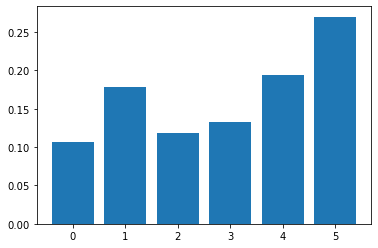

In [45]:
plt.bar(np.arange(len(ppc_hyper_ms)), ppc_hyper_ms)

Did not plot one participant who was always right
Did not plot one participant who was always right
Did not plot one participant who was always right
Did not plot one participant who was always right
Did not plot one participant who was always right


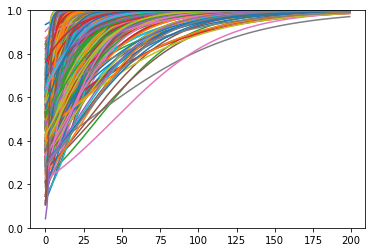

In [46]:
xs, ys = np.indices(ppc_chosen_scenes.shape)
true_by_trial = (
    scenes_trials[xs, ys, ppc_chosen_scenes] 
    == true_scenes_trials
).all(-1)

# plot the participants' estimated probability
# of getting answers right
# by trial (it should increase)
xs = np.arange(len(ys)).reshape(-1,1)
for i, ys in enumerate(true_by_trial.T):
    try:
        clf = LogisticRegression().fit(
            xs, 
            ys
        )
        plt.plot(clf.predict_proba(xs).T[1], label=i)
    
    except ValueError:
        print('Did not plot one participant who was always right')

# plt.legend()
plt.ylim(0,1)
plt.show()

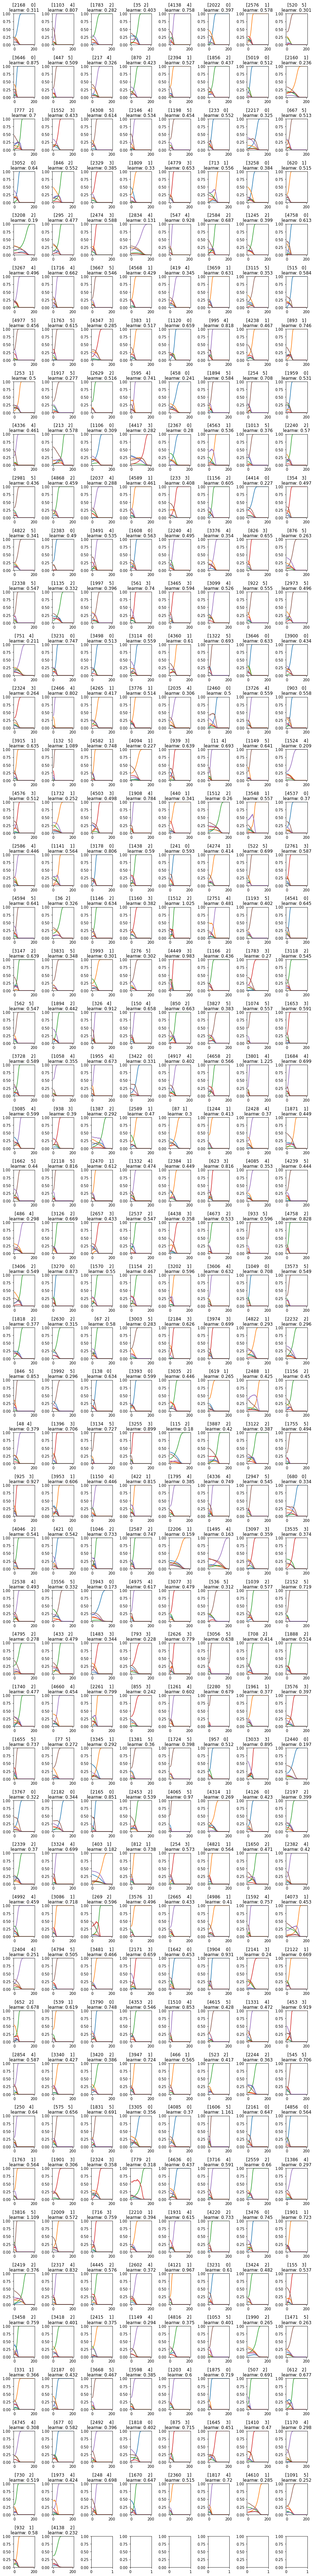

In [47]:
# Plot the probability of each word order by trial
# for each participant

n_partic = ppc_p_wordorders.shape[1]

n_rows, n_cols = np.ceil(n_partic / 8).astype(int), 8
fig, axes = plt.subplots(
    n_rows,
    n_cols, 
    figsize=(12,2*n_rows)
)
for i, j in enumerate(ppc_p_wordorders.swapaxes(0, 1)):
    ax = axes.flatten()[i]
    ax.set_title(
        str(indices_true_language[i]) 
        + f'\nlearnw: {round(ppc_learning_weights[i],3)}'
    )
    ax.plot(j)
    ax.set_ylim(0,1)
plt.tight_layout()
# plt.show()
plt.savefig('prior_samples.png', dpi=300)

##### Recover parameter

In [48]:
ppc_model = factory_weight_model_multiple_participants(
    true_scenes_trials,
    signals,
    word_orders,
    ppc_chosen_scenes,
    scenes_trials
)

In [49]:
with ppc_model:
    ppc_fit = pm.fit()

Interrupted at 710 [7%]: Average Loss = 25,291


with ppc_model:
    ppc_trace = pm.sample(return_inferencedata=True)

In [ ]:
with model:
    ppc_fit_samples = az.from_pymc3(
        ppc_fit.sample(1000)
    )

In [ ]:
for true_value, samples in zip(
                simulated_data['hyper_ms'].flatten(), 
                ppc_fit_samples.posterior.hyper_ms.values.reshape(-1,6).T
            ):
    sns.displot(samples)
    plt.axvline(true_value)
    plt.xlim(0, 0.5)
    plt.show()

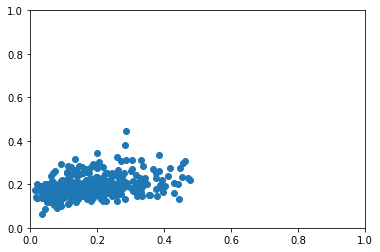

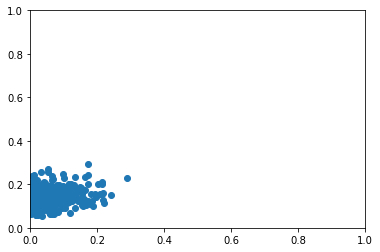

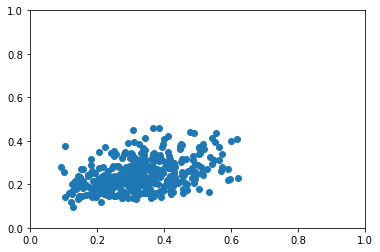

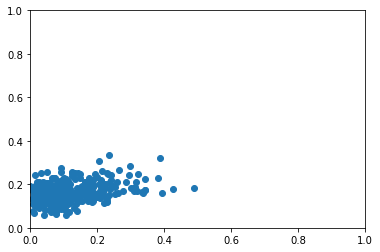

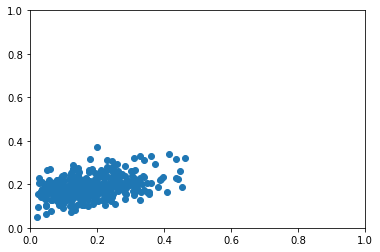

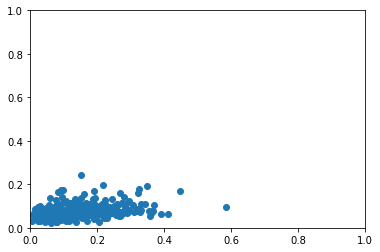

In [883]:
for i in range(6):
    plt.scatter(
        # true word order priors
        ppc_word_order_prior[:,i],
        # mean of estimated word order prior
        ppc_fit_samples.posterior.word_order_prior.values[0].mean(0)[:,i]
    )
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.show()

### Fit pilot data

In [25]:
data = get_data()

In [26]:
analysis_arrays = get_analysis_arrays(data)

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [27]:
scenes, languages, language_interpret, word_orders = define_objects(
    full_output=True
)

In [28]:
word_order_partic = analysis_arrays['word_order_partic'] 
interpretation_fs_partic = analysis_arrays['interpretation_fs_partic'] 
scenes_trials = analysis_arrays['scenes_trials'] 
true_scenes_trials = analysis_arrays['true_scenes_trials'] 
signals = analysis_arrays['signals'] 
history_choices_indices = analysis_arrays['history_choices_indices']
orders = analysis_arrays['orders']

In [33]:
model = factory_weight_model_multiple_participants(
    true_scenes_trials,
    signals,
    word_orders,
    history_choices_indices,
    scenes_trials
)

In [37]:
with model:
    fit = pm.fit(n=50000)

Interrupted at 47,401 [94%]: Average Loss = 96,166


In [ ]:
saveparam = [(param.name, param.eval()) for param in approx.approx.params]

In [ ]:
for i, param in enumerate(saveparam):
    approx2.approx.params[i].set_value(param[1])

In [38]:
with model:
    fit_samples = az.from_pymc3(fit.sample(1000))

In [39]:
az.to_netcdf(fit_samples, 'data_fit.cdf')

'data_fit.cdf'

In [41]:
fit_samples.posterior

<xarray.Dataset>
Dimensions:           (chain: 1, draw: 1000, word_order: 6, participant: 386)
Coordinates:
  * chain             (chain) int64 0
  * draw              (draw) int64 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * word_order        (word_order) int64 0 1 2 3 4 5
  * participant       (participant) int64 0 1 2 3 4 5 ... 381 382 383 384 385
Data variables:
    hyper_gammas      (chain, draw, word_order) float64 1.782 1.261 ... 0.5887
    hyper_alpha       (chain, draw) float64 7.624 7.367 7.851 ... 7.615 7.71
    hyper_ms          (chain, draw, word_order) float64 0.2337 ... 0.07636
    word_order_prior  (chain, draw, participant, word_order) float64 0.2701 ....
    learning_weights  (chain, draw, participant) float64 0.1208 ... 0.1183
Attributes:
    created_at:                 2022-10-18T06:27:39.844965
    arviz_version:              0.12.1
    inference_library:          pymc3
    inference_library_version:  3.11.2

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/arviz/plots/plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (386) in plot_posterior, generating only 40 plots
  warnings.warn(


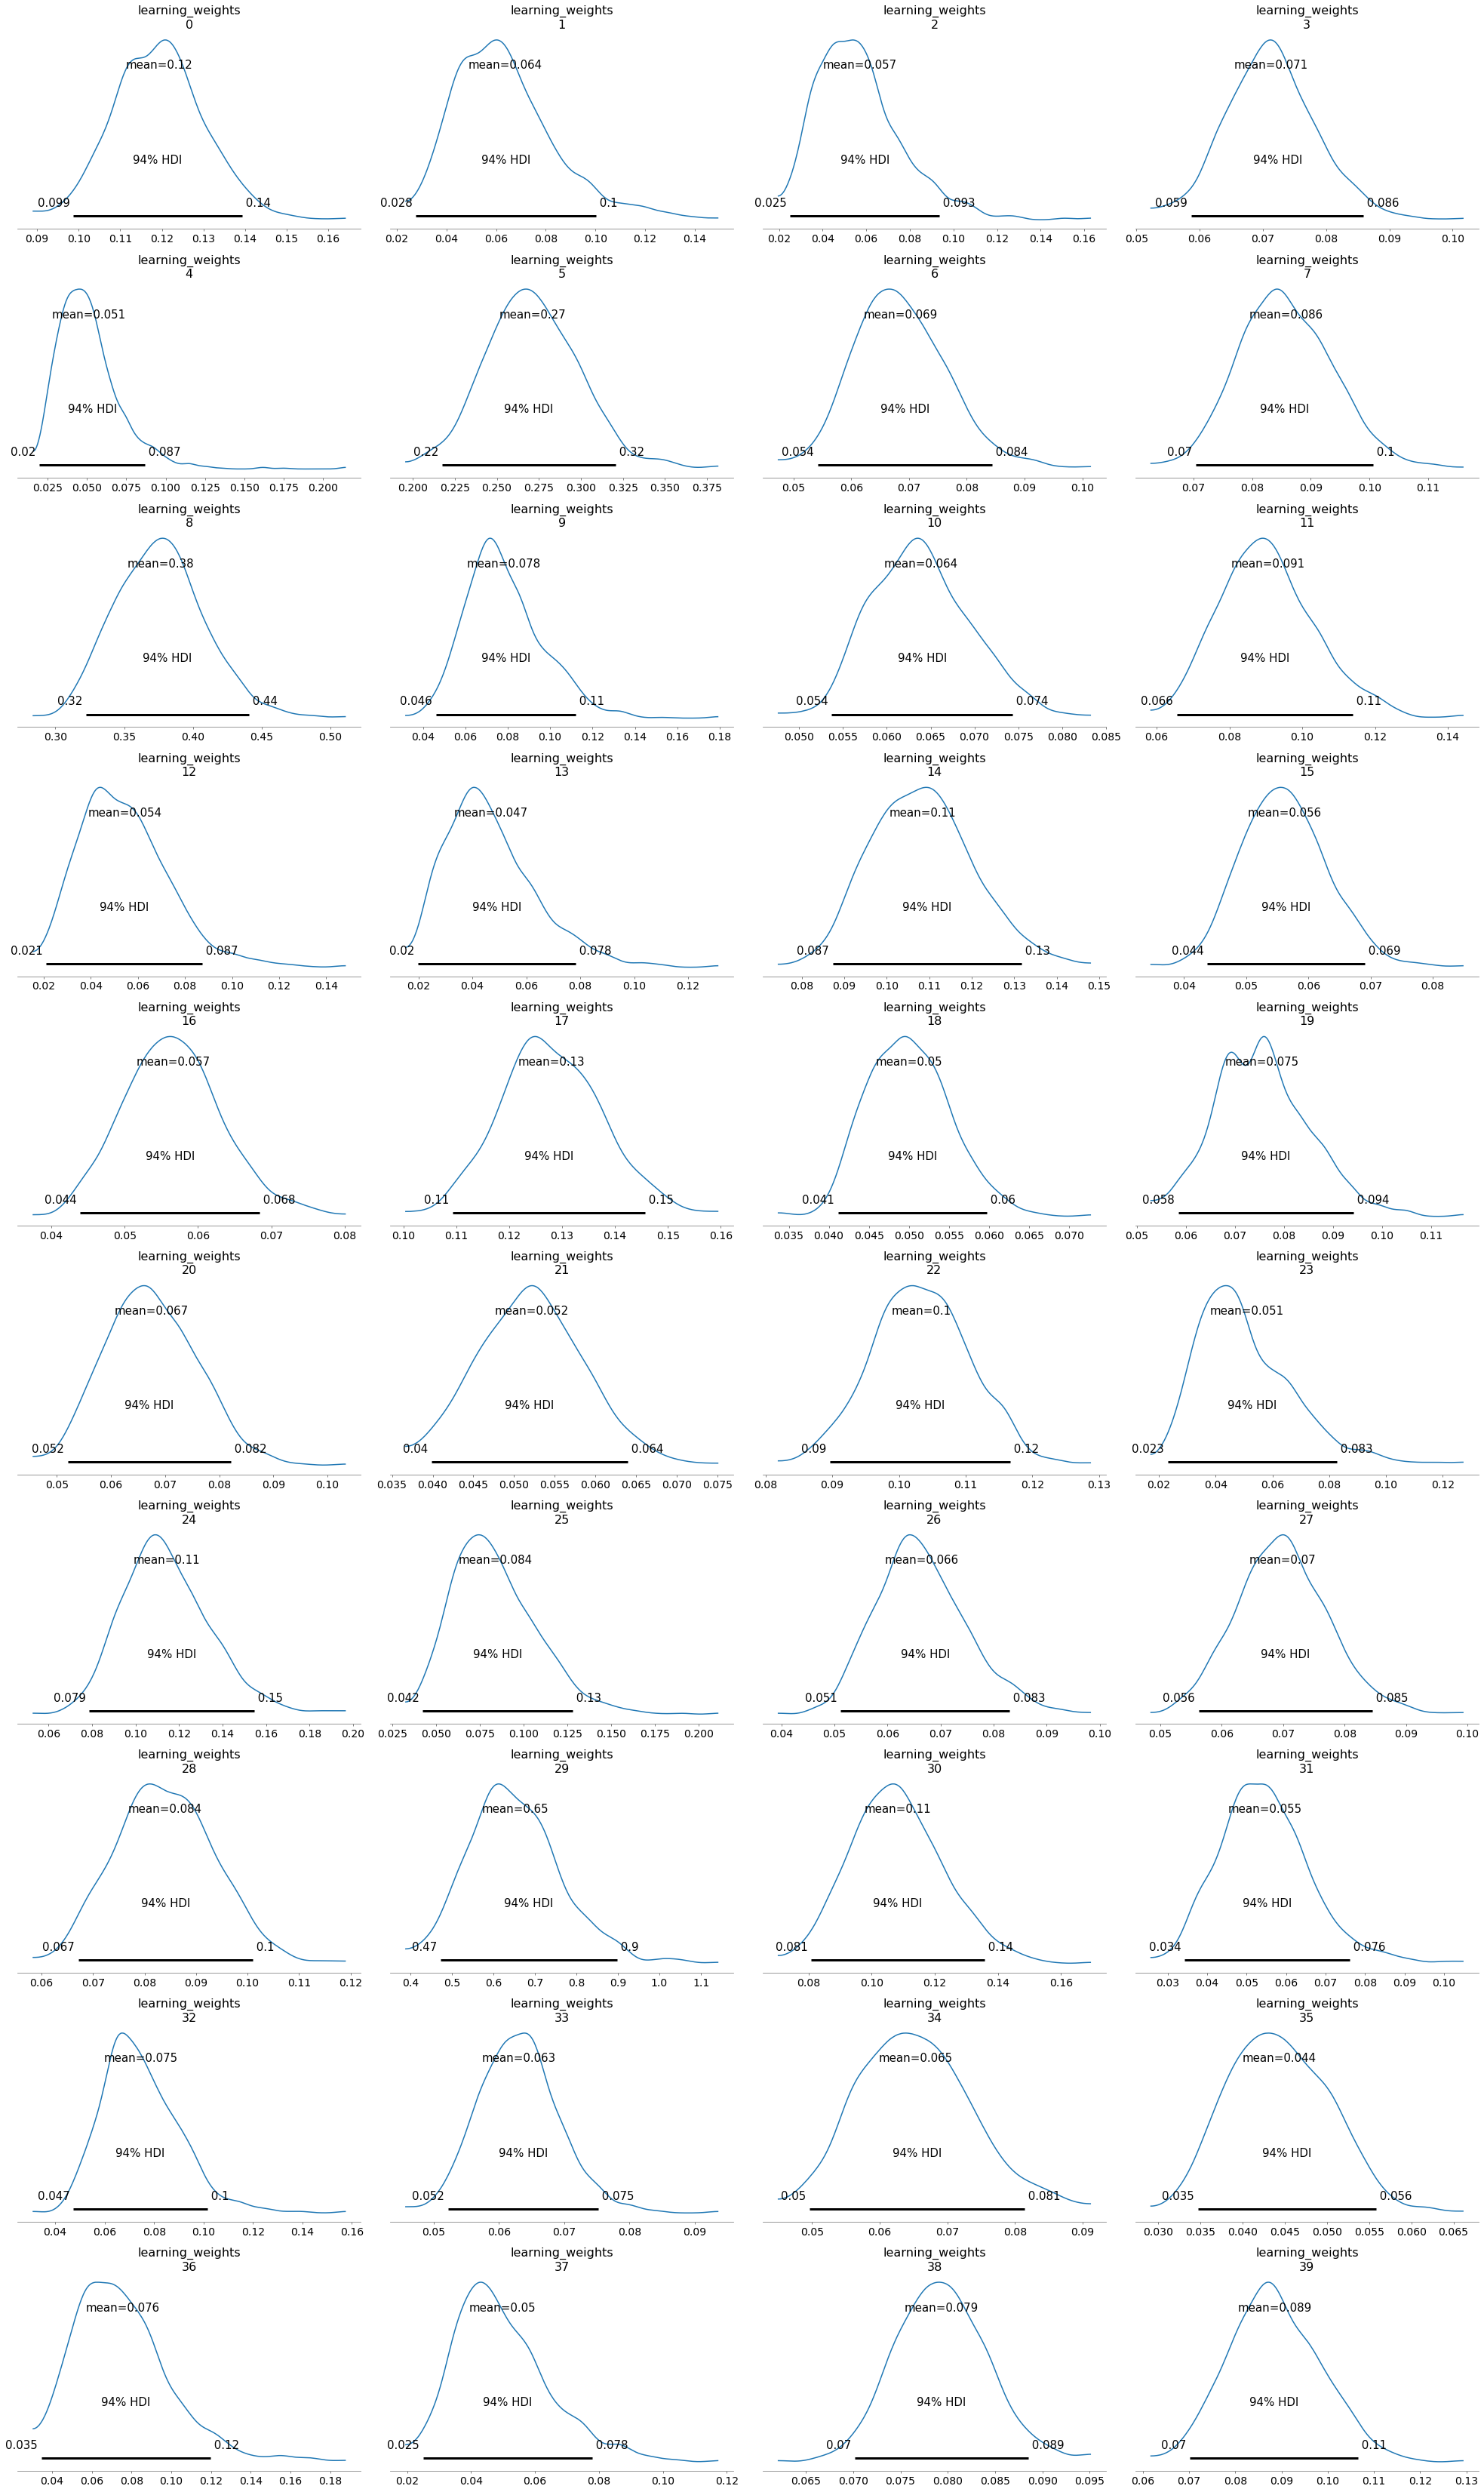

In [43]:
az.plot_posterior(
    fit_samples,
    var_names='learning_weights'
)
plt.tight_layout()
plt.show()

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/arviz/plots/traceplot.py:212: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (2715), generating only 20 plots
  warnings.warn(


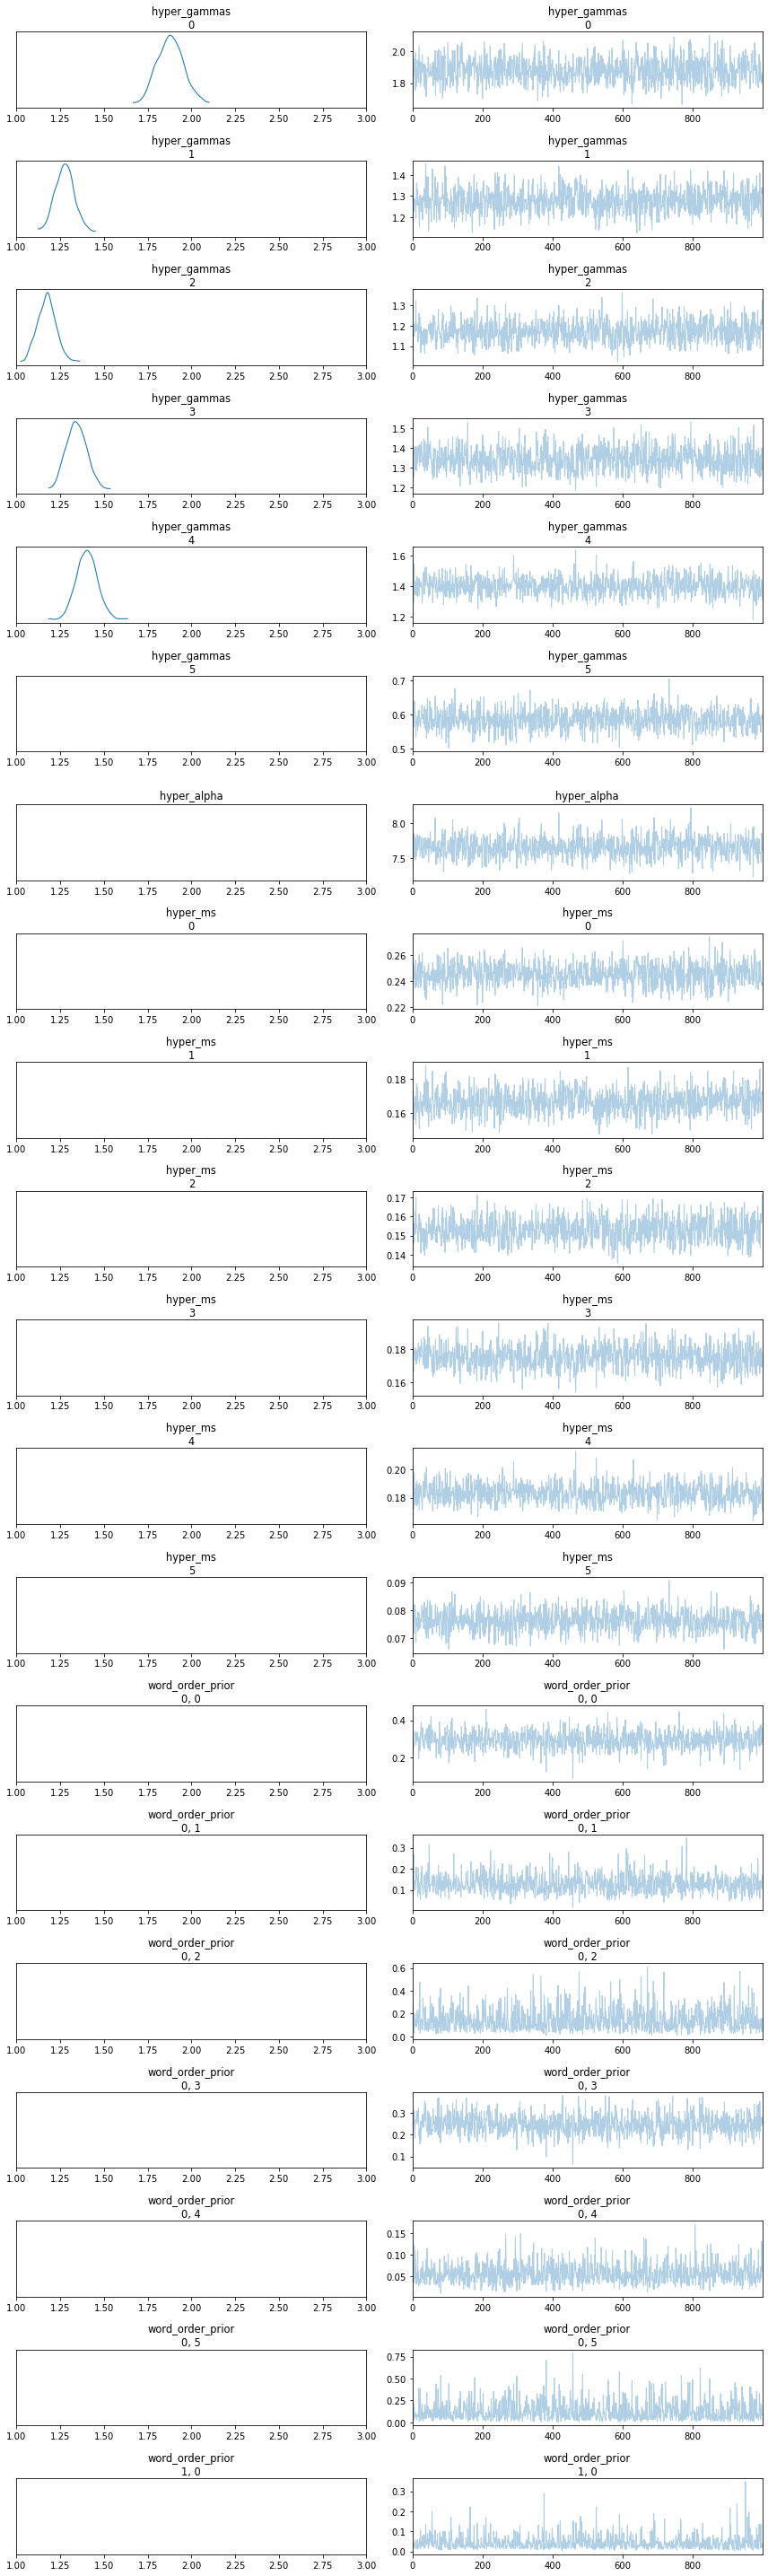

In [45]:
axes = az.plot_trace(fit_samples, compact=False)
[ax.set_xlim(1, 3) for ax in axes[:,0]]
plt.tight_layout()
plt.show()

# TODO

- SOme people said they took notes - check if this correlates with which mode they belong to
- Look at MAP estimate
- Do switchpoint analysis on going from some slope to slope = 1?
- Model:
    - Run a grid approximation of the hyperparameter space (the logp of the model for a bunch of values)

# Old

## Fitting theory-free model 

In [313]:
with pm.Model() as model_wo_switch:
    
    # sample the correlation matrix 
    # (including variance!)
    # of joint of alphas and betas 
    # at the population level
    
    sd_dist = pm.Exponential.dist(1.)
    
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol", 
        n=2, 
        eta=2, 
        sd_dist=sd_dist, 
        compute_corr=True,
        store_in_trace=True
    )
    
    # sample mean of population-level
    # joint distribution over alphas and betas
    alpha_mu = pm.Normal(
        "alpha_mu", 
        0.0, 
        2.0
    )
    
    beta_mu = pm.Normal(
        "beta_mu", 
        0.0, 
        2.0, 
    )
    
    # sample alphas and betas from 
    # the joint distribution
    # (one per participant)
    partic_params = pm.MvNormal(
        "pop_params", 
        [alpha_mu, beta_mu], 
        chol=chol,
        shape=(
            participant.max()+1,
            2
        )
    )
    
    tprint()(partic_params.shape)
        
    # predicted probability of answer
    logit_ps = (
        partic_params[participant,0] + 
        partic_params[participant,1] * 
        trial
    )
    
    pm.Bernoulli(
        'correct',
        logit_p = logit_ps,
        observed=right_answers
    )

 __str__ = [386   2]


### Prior samples

In [314]:
with model_wo_switch:
    prior_samples_wo_switch = pm.sample_prior_predictive(
        samples=50
    )

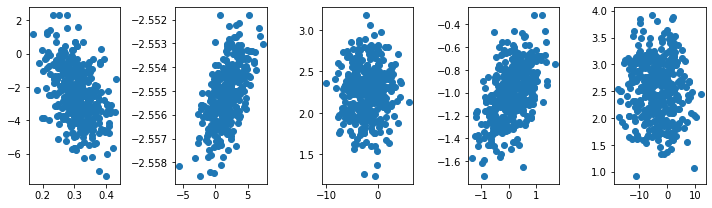

In [315]:
fig, axes = plt.subplots(1,5,figsize=(10,3))
for i, ax in enumerate(axes):
    ax.scatter(*prior_samples_wo_switch['pop_params'][i].T)
plt.tight_layout()

### Variational

In [88]:
with model_wo_switch:
    fit_wo_switch = pm.fit()

Finished [100%]: Average Loss = 2.7389e+05


In [89]:
samples_from_fit_wo_switch = fit_wo_switch.sample(1000)

/home/fausto/anaconda3/envs/argumentative_language/lib/python3.8/site-packages/arviz/plots/plot_utils.py:271: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (783) in plot_posterior, generating only 40 plots
  warnings.warn(


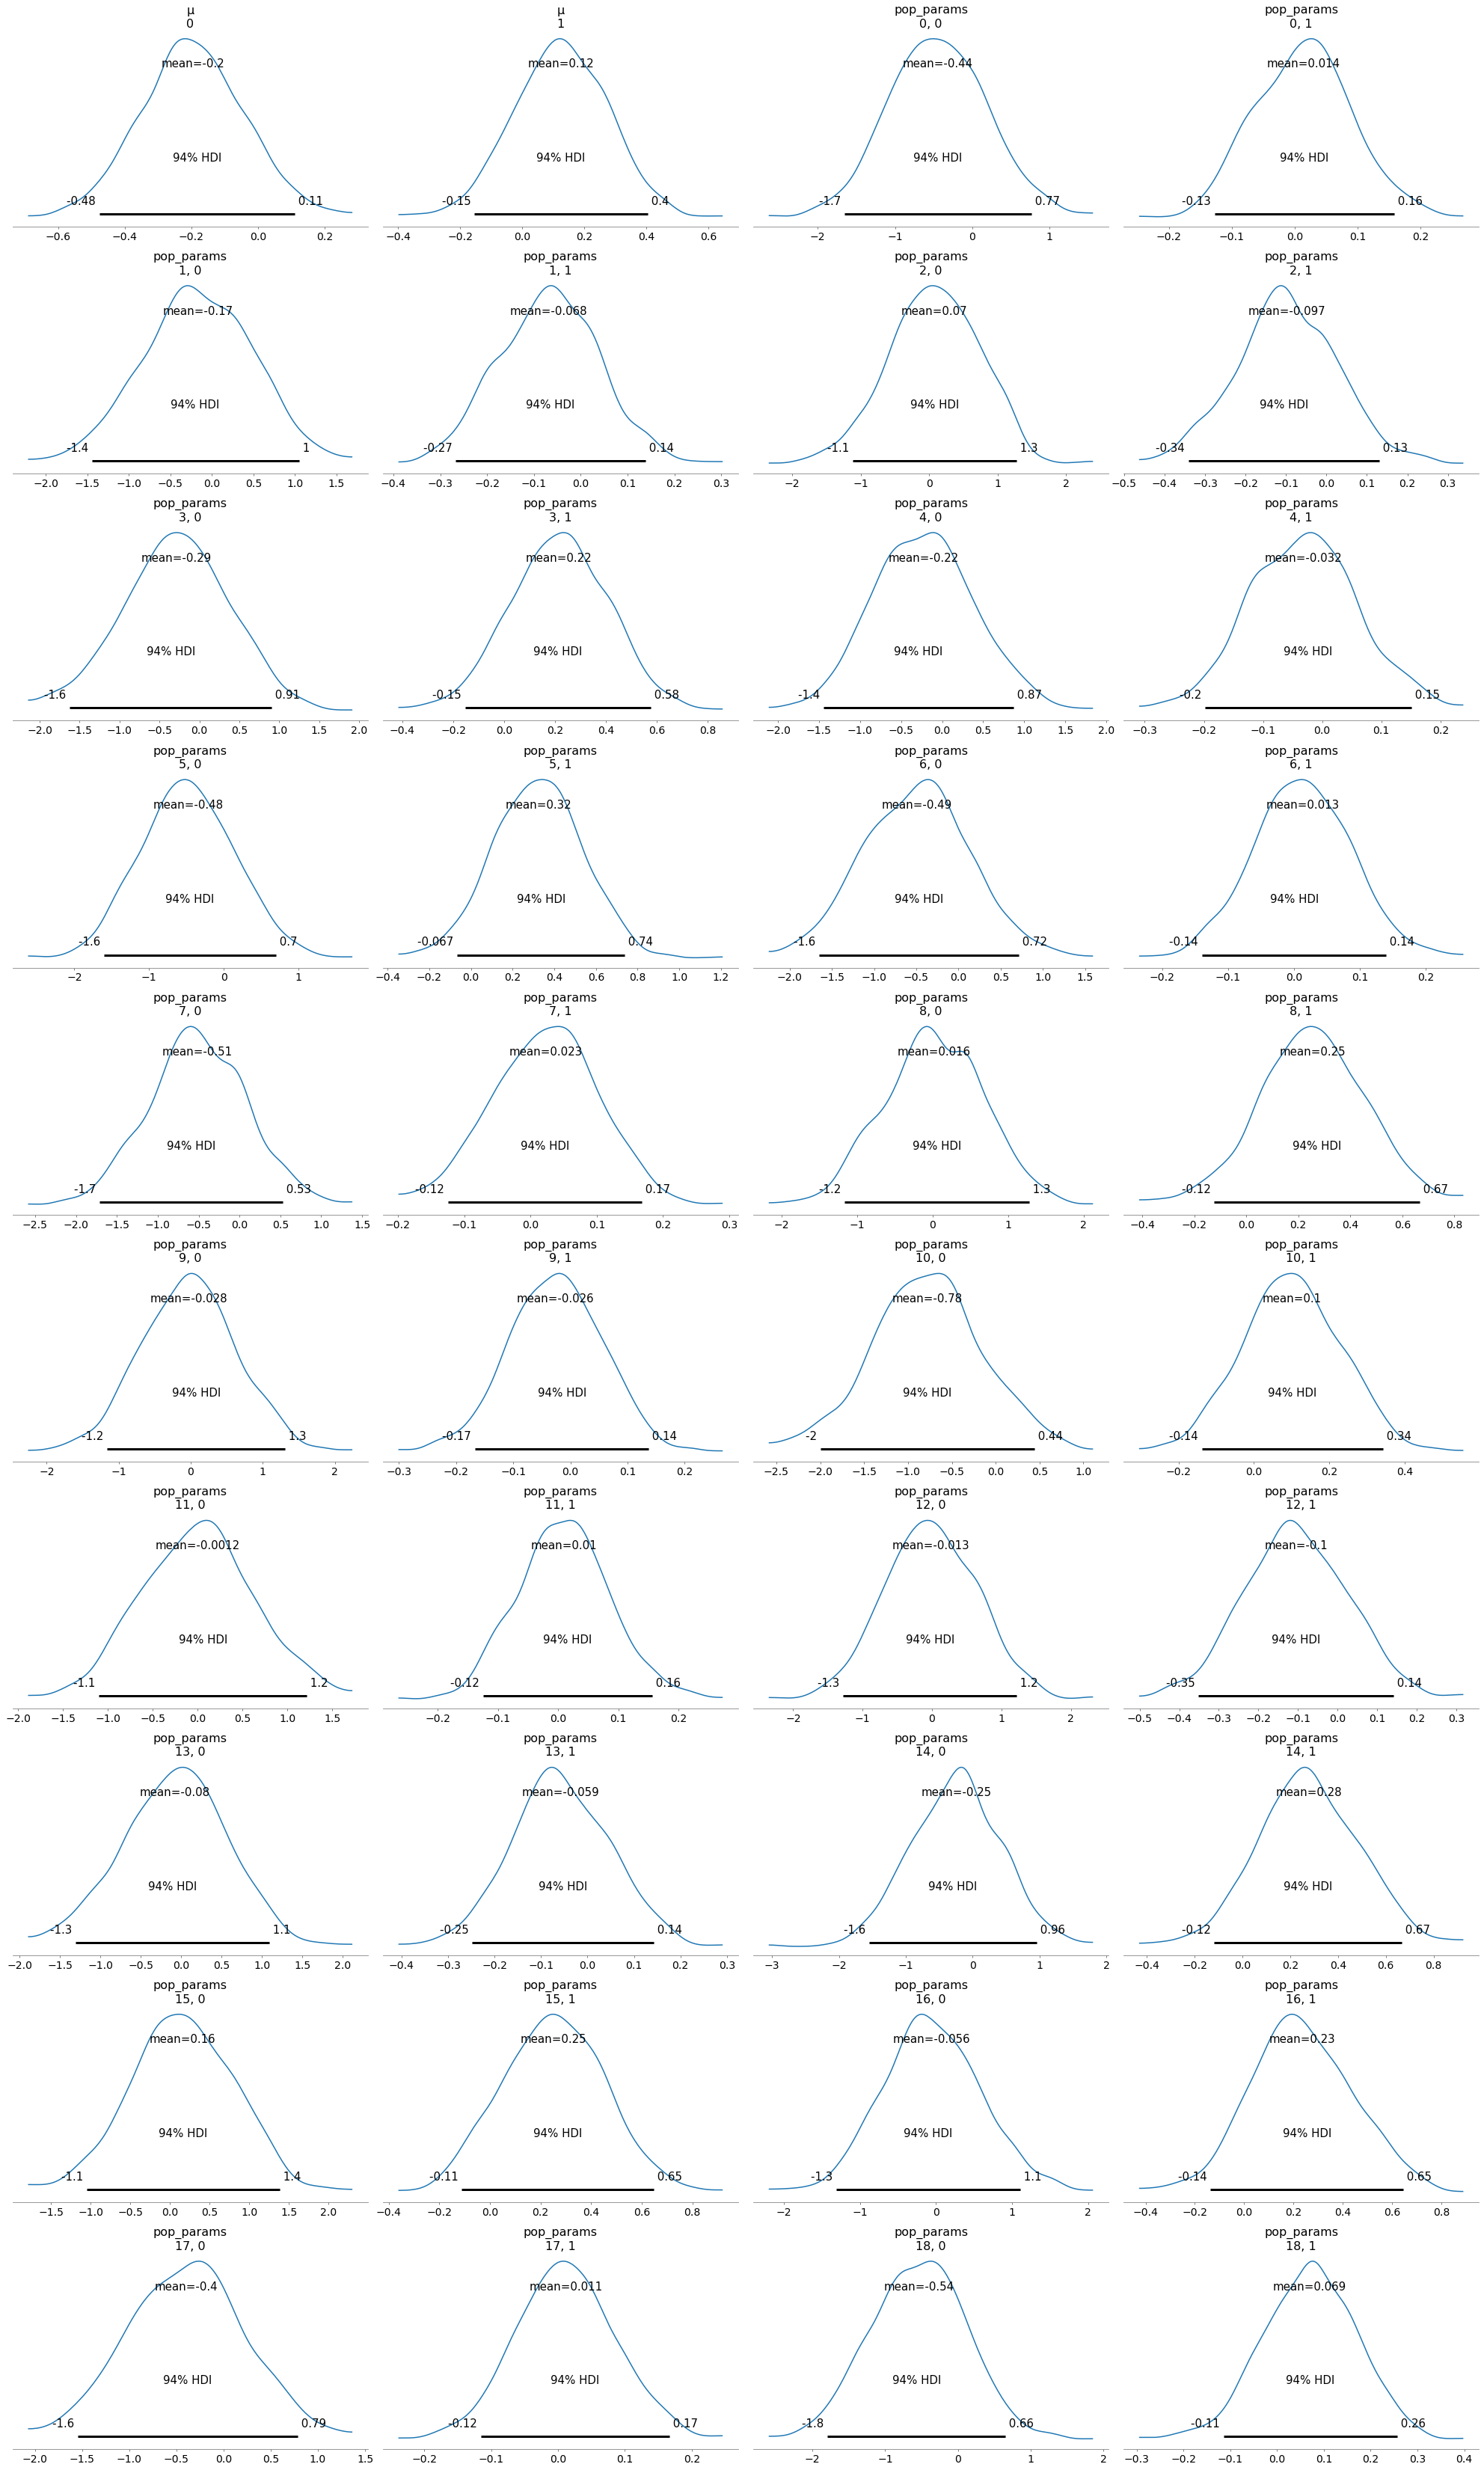

In [90]:
with model_wo_switch:
    az.plot_posterior(
        samples_from_fit_wo_switch
    )
plt.tight_layout()
plt.show()

### MAP analysis

In [101]:
from scipy.special import expit
from pprint import pprint

In [309]:
with model_wo_switch:
    MAP_wo_switch = pm.find_MAP()

Text(0, 0.5, '$\\beta$')

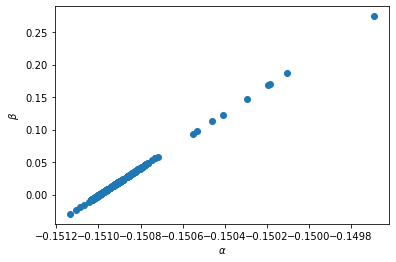

In [310]:
plt.scatter(
    *MAP_wo_switch['pop_params'].T
)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$\beta$')

In [311]:
MAP_alphas, MAP_betas = MAP_wo_switch['pop_params'].T

ps_right = expit(
    MAP_alphas[participant] + 
    MAP_betas[participant] * 
    trial
)

MAP_df = pd.DataFrame({
    'p_right': ps_right,
    'part': participant,
    'trial': trial,
    'order': word_order_partic['response'].values[participant]
})

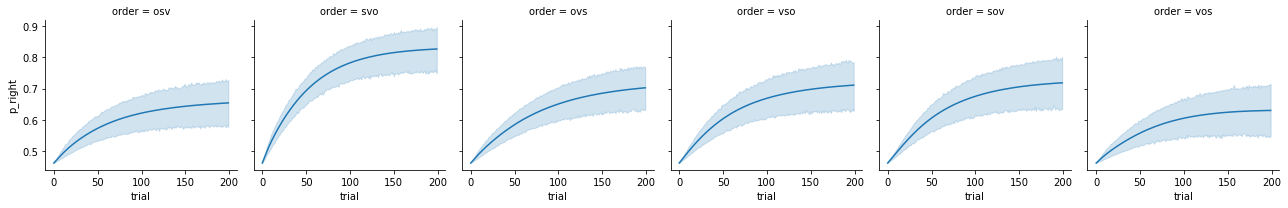

In [312]:
g = sns.FacetGrid(
    MAP_df,
    col='order',
    # hue='part'
)
    
g.map(
    sns.lineplot,
    'trial',
    'p_right'
)

### HMC sampling (Too slow!)

In [301]:
with model_wo_switch:
    trace_wo_switch = pm.sample(
        return_inferencedata=True
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pop_params, beta_mu, alpha_mu, chol]


ValueError: Not enough samples to build a trace.

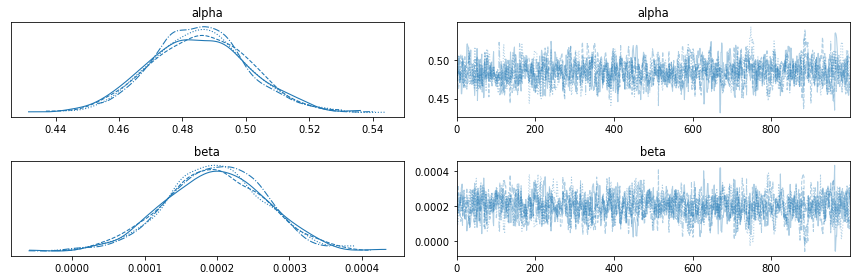

In [128]:
az.plot_trace(trace_wo_switch)
plt.tight_layout()

## Model with word order and participant structure

In [101]:
with pm.Model() as model_wo_switch:
    
    ################ Word-order-wise parameters
    
    sd_dist_wordorder = pm.Exponential.dist(0.5)
    
    chol_wordorder, _, _ = pm.LKJCholeskyCov(
        "chol_wordorder", 
        n=2, 
        eta=1.0, 
        sd_dist=sd_dist_wordorder, 
        compute_corr=True,
        store_in_trace=True
    )
    
    alpha_mu_wordorder = pm.Normal(
        "alpha_mu_wordorder", 
        0.0, 
        2.0
    )
    
    beta_mu_wordorder = pm.Normal(
        "beta_mu_wordorder", 
        0.0, 
        2.0, 
    )
    
    params_wordorder = pm.MvNormal(
        "pop_params_wordorder", 
        [alpha_mu_wordorder, beta_mu_wordorder], 
        chol=chol_wordorder,
        shape=(
            6,
            2
        )
    )
    
    ################ Participant-wise parameters
    
    sd_dist_partic = pm.Exponential.dist(0.5)
    
    # sample correlation of joint of
    # alphas and betas at the population level
    chol_partic, _, _ = pm.LKJCholeskyCov(
        "chol_partic", 
        n=2, 
        eta=1.0, 
        sd_dist=sd_dist_partic, 
        compute_corr=True,
        store_in_trace=True
    )
    
    # sample mean of population-level
    # joint distribution over alphas and betas
    alpha_mu_partic = pm.Normal(
        "alpha_mu_partic", 
        0.0, 
        2
    )
    
    beta_mu_partic = pm.Normal(
        "beta_mu_partic", 
        0.0, 
        2, 
    )
    
    # sample alphas and betas from 
    # the joint distribution
    # (one per participant)
    params_partic = pm.MvNormal(
        "pop_params_partic", 
        [alpha_mu_partic, beta_mu_partic], 
        chol=chol_partic,
        shape=(
            participant.max()+1,
            2
        )
    )
        
    ###################### LIKELIHOOD
    
    # Make predictions for each datapoint
    # that only depend on the word order
    # of the participant
    logit_ps_wordorder = (
        params_partic[participant,0] + 
        trial * params_partic[participant,1]
    )
    
    # Add the participant-dependent
    # effect
    # predicted probability of answer
    logit_ps = logit_ps_wordorder + (
        params_wordorder[wordorder,0] +
        trial * params_wordorder[wordorder,1]
    )
    
    pm.Bernoulli(
        'correct',
        logit_p = logit_ps,
        observed=right_answers
    )

### Prior samples

In [245]:
with model_wo_switch:
    prior_samples_wo_switch = pm.sample_prior_predictive(
        samples=50
    )

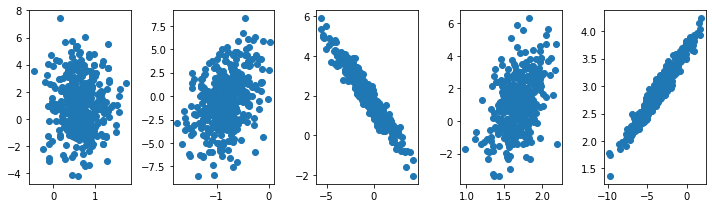

In [246]:
fig, axes = plt.subplots(1,5,figsize=(10,3))
for i, ax in enumerate(axes):
    ax.scatter(*prior_samples_wo_switch['pop_params_partic'][i].T)
plt.tight_layout()

### MAP analysis

In [102]:
from scipy.special import expit
from pprint import pprint

In [103]:
with model_wo_switch:
    MAP_wo_switch = pm.find_MAP()

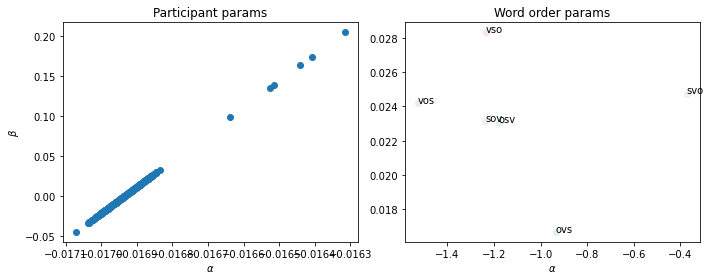

In [251]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))

ax1.scatter(
    *MAP_wo_switch['pop_params_partic'].T
)
ax1.set_xlabel(r'$\alpha$')
ax1.set_ylabel(r'$\beta$')
ax1.set_title('Participant params')

for i, txt in enumerate(wordorder_codes):
    coords = MAP_wo_switch['pop_params_wordorder'][i]
    ax2.scatter(*coords, alpha=0.1)
    ax2.annotate(
        txt,
        coords
    )
    
ax2.set_xlabel(r'$\alpha$')
ax2.set_title('Word order params')

plt.tight_layout()
plt.show()

In [233]:
MAP_pop_params_partic = MAP_wo_switch['pop_params_partic']
MAP_pop_params_wordorder = MAP_wo_switch['pop_params_wordorder']

ps_right = expit(
    MAP_pop_params_partic[participant,0] + 
    MAP_pop_params_wordorder[wordorder,0] + 
    MAP_pop_params_partic[participant,1] * trial + 
    MAP_pop_params_wordorder[wordorder,1] * trial
)

MAP_df = pd.DataFrame({
    'p_right': ps_right,
    'part': participant,
    'trial': trial,
    'order': word_order_partic['response'].values[participant]
})

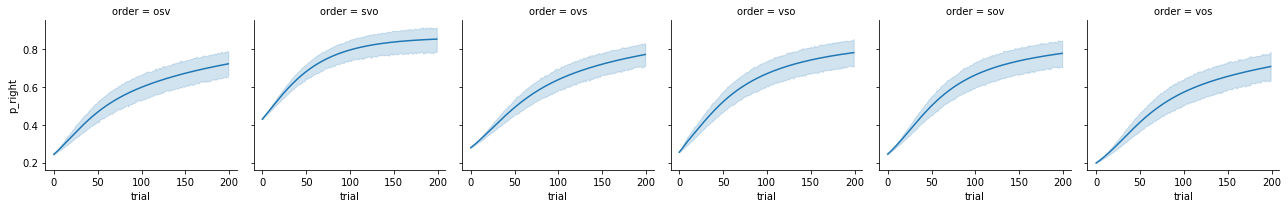

In [234]:
g = sns.FacetGrid(
    MAP_df,
    col='order',
    # hue='part'
)
    
g.map(
    sns.lineplot,
    'trial',
    'p_right'
)

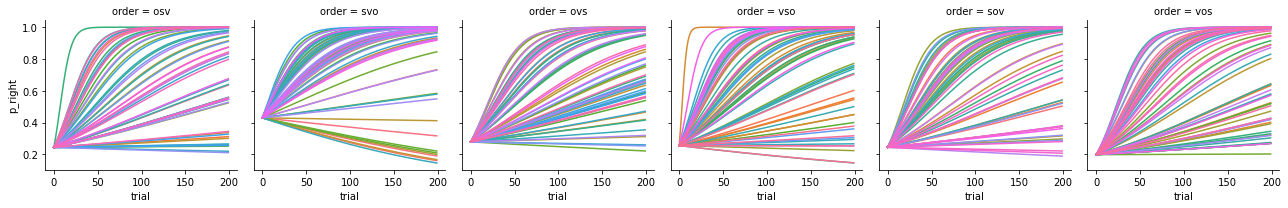

In [235]:
g = sns.FacetGrid(
    MAP_df,
    col='order',
    hue='part'
)
    
g.map(
    sns.lineplot,
    'trial',
    'p_right'
)